# ORACLE — Full Pipeline Inference Example

End-to-end, **closed-loop** demonstration that chains **all three trained ORACLE models**
on a single patient timepoint (`PatientID_0003/Timepoint_1`, the first folder of the
nnU-Net MU-Glioma dataset):

| Stage | Model | Checkpoint | Role |
|-------|-------|-----------|------|
| 0b · Classification | **EfficientNet-B3** (4-class + Grad-CAM) | `models/best_effnetb3_cls.pth` | tumour *type* + explainability — **out-of-distribution demo**, see Stage 0b |
| 1 · Segmentation | **nnU-Net 2D** (EMA + 16-aug TTA) | `models/best_nnunet2d.pth` | 4-channel MRI → binary tumor mask |
| 2 · Reconstruction | **Fast2p5D GAN generator** | `models/G_joint_epoch_022.pth` | sparse known slices → full dense `t1n` volume, *guided by the Stage-1 mask* |
| 3 · Growth | **Inverse Fisher–KPP PINN** | `models/pinn_tumor_growth.pt` | recover patient-specific `D_wm / D_gm / ρ` |
| 4 · Evolution | **FK PDE + nnU-Net + GAN** | (reuses 1–3) | evolve the detected tumor forward, re-segment, GAN-reconstruct → **initial vs evolved** |

The pipeline is a genuine cascade. Stages 1–3 detect, reconstruct, and recover growth
dynamics. **Stage 4 closes the loop**: the PINN-recovered dynamics drive a forward
Fisher–KPP PDE that evolves the *detected* tumor slice-by-slice; the evolved tumor is
composited back into the MRI, **re-segmented** by nnU-Net, and **re-reconstructed** by the
GAN — producing a side-by-side animation of the initial volume vs its predicted future.

> The MU-Glioma NIfTI dataset is not bundled in the repo (it was a Kaggle mount).
> Stage 0b (classification) is optional: if its checkpoint is missing it is skipped and
> Stages 1-4 run unchanged.
>
> Set `ORACLE_DATA_ROOT` (or edit `CFG['data_root']`) to point at your local copy of
> `MU-Glioma-Post/`. Every model-loading and architecture cell runs without the data.

## Running this on Kaggle

This notebook is **inference only** — nothing here trains. Three steps:

1. **Add Data → Datasets** → search `prishapgpg/pkg-mu` (MU-Glioma-Post NIfTI volumes).
2. **Add Data → Models** → search `aneurisma/oracle-pipeline` and attach the latest version.
3. **Settings → Accelerator → GPU**, then Run All.

The preflight cell below stops immediately with instructions if either mount is
missing, rather than failing ten cells later with an opaque error.

Stage 0b (classification) is **optional**: if `best_effnetb3_cls.pth` is absent the
notebook warns once and Stages 1–4 run unchanged.

Prefer not to attach anything? [`demo_full_run_executed.ipynb`](demo_full_run_executed.ipynb)
is this same notebook already executed, with every figure and output retained.


In [1]:
import os
import glob
import re
import random
from pathlib import Path
from typing import Dict, List
!pip install ttach
import cv2
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
DTYPE = torch.float32
print('Device:', DEVICE)

PROJECT_ROOT = Path("/kaggle/input/datasets/prishapgpg/pkg-mu/PKG - MU-Glioma-Post/MU-Glioma-Post")
# The Kaggle model mount is version-pinned, so probe newest-first. Resolution is
# PER FILE, not per directory: publishing a new model version that contains only
# some checkpoints (e.g. just the classifier) must not orphan the others.
def _kaggle_model_dirs():
    """Every mounted version of the oracle-pipeline model, newest version first.

    Kaggle mounts models at <owner>/<slug>/<framework>/<variation>/<version>, and
    BOTH the variation name and the version number change as you publish — one run
    of this notebook resolved under 'pytorch/hybrid/2', another under
    'pytorch/default/1'. Globbing beats hardcoding: a hardcoded 'default/2' simply
    misses a model that landed under 'hybrid/2', and the run dies on the first
    checkpoint load.
    """
    hits = [d for d in glob.glob('/kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2')
            if os.path.isdir(d)]
    # Numeric sort on the trailing version so 10 outranks 9.
    return sorted(hits, key=lambda d: (int(os.path.basename(d))
                                       if os.path.basename(d).isdigit() else -1),
                  reverse=True)


_MODEL_DIR_CANDIDATES = [
    os.environ.get('ORACLE_MODELS_DIR', ''),
    *_kaggle_model_dirs(),
    "models",
]

# Candidate locations for the MU-Glioma-Post NIfTI dataset (first match wins).
_DATA_CANDIDATES = [
    os.environ.get('ORACLE_DATA_ROOT', ''),
    str(PROJECT_ROOT / 'data' / 'MU-Glioma-Post'),
    '/kaggle/input/datasets/prishapgpg/pkg-mu/PKG - MU-Glioma-Post/MU-Glioma-Post',
]

def _first_existing_dir(cands: List[str]):
    for c in cands:
        if c and Path(c).is_dir():
            return Path(c)
    return None

_MODEL_DIRS = [Path(d) for d in _MODEL_DIR_CANDIDATES if d and Path(d).is_dir()]


def _find_ckpt(name: str) -> Path:
    """Newest-first search for one checkpoint across every available model mount.

    Per-file rather than per-directory, so a model version holding only the
    classifier still lets the segmenter/GAN/PINN resolve back to the older
    version. `.is_file()` (not `.exists()`) also rejects the Kaggle
    auto-extraction case, where a .pth — internally a zip — arrives unpacked
    as a *directory* of its own internals.
    """
    for d in _MODEL_DIRS:
        p = d / name
        if p.is_file():
            return p
    # Nothing found: return a path under the first mount so the caller's
    # exists-check reports a sensible location rather than crashing here.
    return (_MODEL_DIRS[0] if _MODEL_DIRS else Path('models')) / name


print('model dirs:', [str(d) for d in _MODEL_DIRS] or '(none found)')

CFG = {
    'data_root': _first_existing_dir(_DATA_CANDIDATES),
    'patient': 'PatientID_0003',
    'timepoint': 'Timepoint_1',
    'img_size': 256,
    'mask_threshold': 0.50,
    'seg_ckpt': _find_ckpt('best_nnunet2d.pth'),
    'gan_ckpt': _find_ckpt('G_joint_epoch_022.pth'),
    'pinn_ckpt': _find_ckpt('pinn_tumor_growth.pt'),
    'cls_ckpt': _find_ckpt('best_effnetb3_cls.pth'),    # Stage 0b (optional)
    'out_dir': Path('/kaggle/working/full_pipeline'),
    'gif_fps': 8,
}
CFG['out_dir'].mkdir(parents=True, exist_ok=True)

for k in ('seg_ckpt', 'gan_ckpt', 'pinn_ckpt', 'cls_ckpt'):
    print(f"{k:10s}: {CFG[k]}  exists={CFG[k].exists()}")
print('data_root :', CFG['data_root'])
if CFG['data_root'] is None:
    print('  [!] Dataset not found — set ORACLE_DATA_ROOT to your MU-Glioma-Post folder.')


Device: cuda
model dirs: ['/kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2']
seg_ckpt  : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/best_nnunet2d.pth  exists=True
gan_ckpt  : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/G_joint_epoch_022.pth  exists=True
pinn_ckpt : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/pinn_tumor_growth.pt  exists=True
cls_ckpt  : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/best_effnetb3_cls.pth  exists=True
data_root : /kaggle/input/datasets/prishapgpg/pkg-mu/PKG - MU-Glioma-Post/MU-Glioma-Post


In [2]:
# Preflight — fail here, with instructions, rather than ten cells downstream.
_REQUIRED = {
    'seg_ckpt':  ('best_nnunet2d.pth',      'Stage 1 segmentation'),
    'gan_ckpt':  ('G_joint_epoch_022.pth',  'Stage 2 reconstruction'),
    'pinn_ckpt': ('pinn_tumor_growth.pt',   'Stage 3 growth PINN'),
}
_problems = []
if CFG['data_root'] is None:
    _problems.append(
        "MU-Glioma-Post dataset not found.\n"
        "      Kaggle : Add Data -> Datasets -> search 'prishapgpg/pkg-mu'\n"
        "      Local  : export ORACLE_DATA_ROOT=/path/to/MU-Glioma-Post"
    )
for _key, (_fname, _stage) in _REQUIRED.items():
    if not Path(CFG[_key]).is_file():
        _problems.append(
            f"{_fname} not found ({_stage}).\n"
            f"      Kaggle : Add Data -> Models -> search 'aneurisma/oracle-pipeline'\n"
            f"      Local  : export ORACLE_MODELS_DIR=/path/to/checkpoints\n"
            f"      Looked in: {[str(d) for d in _MODEL_DIRS] or '(no model dir exists)'}"
        )

if _problems:
    _msg = "\n\n".join(f"  [{i}] {p}" for i, p in enumerate(_problems, 1))
    raise FileNotFoundError(
        f"\n\nPreflight failed - {len(_problems)} missing input(s):\n\n{_msg}\n\n"
        "A .pth that arrives as a *directory* means Kaggle auto-extracted the archive;\n"
        "re-upload it wrapped in a .zip (the training notebook emits one for this reason).\n"
    )

# Stage 0b is a parallel diagnostic branch, not a dependency: warn, do not fail.
if not Path(CFG['cls_ckpt']).is_file():
    print("[!] best_effnetb3_cls.pth not found - Stage 0b (classification) will be SKIPPED.")
    print("    Stages 1-4 are unaffected; metrics.json will carry classification=null.")

print('Preflight OK.')
print(f"  data      : {CFG['data_root']}")
for _key in ('seg_ckpt', 'gan_ckpt', 'pinn_ckpt', 'cls_ckpt'):
    print(f"  {_key:10s}: {CFG[_key]}")


Preflight OK.
  data      : /kaggle/input/datasets/prishapgpg/pkg-mu/PKG - MU-Glioma-Post/MU-Glioma-Post
  seg_ckpt  : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/best_nnunet2d.pth
  gan_ckpt  : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/G_joint_epoch_022.pth
  pinn_ckpt : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/pinn_tumor_growth.pt
  cls_ckpt  : /kaggle/input/models/aneurisma/oracle-pipeline/pytorch/hybrid/2/best_effnetb3_cls.pth


## Stage 0 — Load the patient timepoint

Loads the 4 MRI modalities (`t1n, t1c, t2w, t2f`) and the ground-truth tumor mask for
`PatientID_0003/Timepoint_1`. Volumes are kept at native resolution `[H, W, Z]`; each
2D slice is min-max normalized on the fly (matching training).

In [3]:
def minmax_norm_2d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = float(np.nanmin(x)), float(np.nanmax(x))
    if hi - lo < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo + eps)


def find_modality_file(timepoint_dir: Path, token: str) -> Path:
    files = sorted(list(timepoint_dir.glob('*.nii')) + list(timepoint_dir.glob('*.nii.gz')))
    key = 'mask' if token == 'mask' else token
    cand = [f for f in files if key in f.name.lower()]
    if not cand:
        raise FileNotFoundError(f"Could not find '{token}' in {timepoint_dir}")
    return cand[0]


def load_timepoint_volumes(timepoint_dir: Path) -> Dict[str, np.ndarray]:
    paths = {m: find_modality_file(timepoint_dir, m)
             for m in ('t1n', 't1c', 't2w', 't2f', 'mask')}
    vols = {k: nib.load(str(p)).get_fdata(dtype=np.float32) for k, p in paths.items()}
    base = vols['t1n'].shape
    for k, v in vols.items():
        if v.shape != base:
            raise ValueError(f'Shape mismatch: {k} {v.shape} vs {base}')
    return vols


if CFG['data_root'] is None:
    raise FileNotFoundError(
        'Dataset not available. Set ORACLE_DATA_ROOT to a MU-Glioma-Post folder '
        'containing PatientID_0003/Timepoint_1, then re-run from here.')

demo_tp = CFG['data_root'] / CFG['patient'] / CFG['timepoint']
print('Demo timepoint:', demo_tp, '| exists:', demo_tp.exists())

patient = load_timepoint_volumes(demo_tp)
H, W, Z = patient['t1n'].shape
print(f'Volume shape (H, W, Z): {(H, W, Z)}')
print(f'GT tumor voxels: {int((patient["mask"] > 0).sum()):,}')


Demo timepoint: /kaggle/input/datasets/prishapgpg/pkg-mu/PKG - MU-Glioma-Post/MU-Glioma-Post/PatientID_0003/Timepoint_1 | exists: True
Volume shape (H, W, Z): (240, 240, 155)
GT tumor voxels: 84,540


Tumor-centroid slice z = 55


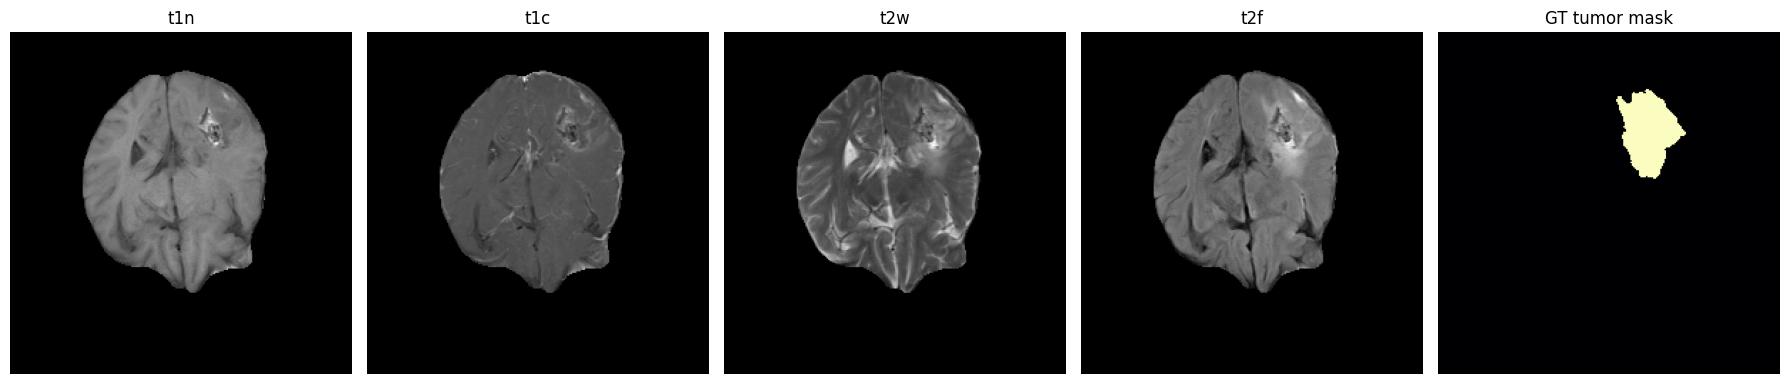

In [4]:
# Visualize the 4 input modalities + GT mask at the tumor-centroid slice
mask_bin = (patient['mask'] > 0).astype(np.float32)
z_tumor = int(np.argmax(mask_bin.sum(axis=(0, 1)))) if mask_bin.sum() > 0 else Z // 2
print('Tumor-centroid slice z =', z_tumor)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for a, mod in zip(ax[:4], ('t1n', 't1c', 't2w', 't2f')):
    a.imshow(np.rot90(minmax_norm_2d(patient[mod][:, :, z_tumor])), cmap='gray')
    a.set_title(mod); a.axis('off')
ax[4].imshow(np.rot90(mask_bin[:, :, z_tumor]), cmap='magma')
ax[4].set_title('GT tumor mask'); ax[4].axis('off')
plt.tight_layout(); plt.show()


## Stage 0b — Tumour Type Classification (EfficientNet-B3)

Upstream, **mask-free** diagnostic branch: an ImageNet-pretrained EfficientNet-B3 fine-tuned
on the 4-class `brain-tumor-mri-dataset` (glioma / meningioma / notumor / pituitary), plus
**Grad-CAM** showing which pixels drove the prediction. It runs *before* segmentation and
consumes neither the predicted mask (not computed yet) nor the ground-truth mask — feeding
either would leak the answer into a "prediction".

This is a **parallel** branch: it reports a tumour type and feeds `metrics.json`, but it does
**not** gate Stage 1. The segmenter is class-agnostic, and Stages 1–4 run unchanged whether or
not the classifier checkpoint is present.

> ⚠️ **Out-of-distribution demonstration.** This classifier was trained on
> `masoudnickparvar/brain-tumor-mri-dataset` — 2D JPEG slices of **pre-operative** glioma /
> meningioma / no-tumour / pituitary cases, across mixed scanners and acquisition planes.
> MU-Glioma-Post is **100 % glioma and post-operative** (resection cavities, surgical
> artefact). That distribution is not represented in the training data, and there is no
> ground-truth tumour *type* label here to score against. The prediction below is a
> pipeline-wiring demonstration and **carries no diagnostic weight**. Held-out metrics on the
> classifier's own test split live in `effnet_tumor_classification.ipynb` §10.


In [5]:
# Stage 0b setup — re-declare the classifier so its checkpoint loads standalone.
# (Same convention as nnUNet2D / Fast2p5D / TumorPINN above: every model class is
#  re-declared here so this notebook never imports from the training notebooks.)
import glob

CLS_CFG_DEFAULTS = {
    'classes':    ['glioma', 'meningioma', 'notumor', 'pituitary'],   # frozen, alphabetical
    'img_size':   300,          # B3 native resolution — NOT the segmenter's 256
    'dropout':    0.3,
    'norm_mean':  [0.485, 0.456, 0.406],   # ImageNet — required by the pretrained backbone
    'norm_std':   [0.229, 0.224, 0.225],
    'denoise':    'bilateral',
    'crop_brain': True,
    'pretrained': True,
}


class BrainTumorClassifier(nn.Module):
    """EfficientNet-B3 → 4-class brain-tumour classifier.

    state_dict keys are namespaced under `backbone.` so this class can be
    re-declared verbatim in full_pipeline_testing.ipynb and loaded strict=True.
    The constructor NEVER downloads weights — see load_imagenet_b3_weights().
    """
    def __init__(self, num_classes: int = 4, dropout: float = 0.3):
        super().__init__()
        from torchvision.models import efficientnet_b3
        self.backbone = efficientnet_b3(weights=None)
        in_f = self.backbone.classifier[1].in_features          # 1536
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_f, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


def crop_brain_region(img_u8: np.ndarray, thr: int = 10) -> np.ndarray:
    """Crop the black letterbox around the brain. Identity if nothing is found.

    This dataset's letterboxing varies wildly between source collections; cropping
    before resize keeps the brain at a consistent scale across images.
    """
    m = (img_u8 > thr).astype(np.uint8)
    if m.sum() == 0:
        return img_u8
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 1:
        return img_u8
    k = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    x, y, w, h = (stats[k, cv2.CC_STAT_LEFT], stats[k, cv2.CC_STAT_TOP],
                  stats[k, cv2.CC_STAT_WIDTH], stats[k, cv2.CC_STAT_HEIGHT])
    return img_u8[y:y + h, x:x + w] if w > 8 and h > 8 else img_u8


def preprocess_cls(img_u8: np.ndarray, cfg: dict) -> torch.Tensor:
    """uint8 grayscale → (1,3,S,S) normalized tensor.

    Frozen chain (must stay identical to the training notebook, which asserts
    parity against its own val transform):
      crop_brain_region → resize(S,S) → bilateral → /255 → 3ch → ImageNet norm → CHW
    """
    S = int(cfg['img_size'])
    x = crop_brain_region(img_u8) if cfg.get('crop_brain', True) else img_u8
    x = cv2.resize(x, (S, S), interpolation=cv2.INTER_LINEAR)
    if cfg.get('denoise') == 'bilateral':
        x = cv2.bilateralFilter(x, d=5, sigmaColor=45, sigmaSpace=45)
    elif cfg.get('denoise') == 'nlm':
        x = cv2.fastNlMeansDenoising(x, h=7)
    f = x.astype(np.float32) / 255.0
    f = np.stack([f, f, f], axis=-1)
    f = (f - np.array(cfg['norm_mean'], np.float32)) / np.array(cfg['norm_std'], np.float32)
    return torch.from_numpy(f.transpose(2, 0, 1)).unsqueeze(0)


def load_classifier(path, device=DEVICE):
    """Rebuild a BrainTumorClassifier from a checkpoint (self-contained, no globals).
    Returns (net, cfg, ckpt) — the same 3-tuple shape as load_pinn()."""
    obj = torch.load(path, map_location=device, weights_only=False)
    cfg_l = dict(CLS_CFG_DEFAULTS)
    if isinstance(obj, dict) and 'model_state' in obj:
        cfg_l.update(obj.get('config', {}))
        state, ckpt = (obj.get('ema_state') or obj['model_state']), obj
    else:
        state = obj.get('model_state_dict', obj) if isinstance(obj, dict) else obj
        ckpt = {'config': cfg_l}
    net = BrainTumorClassifier(num_classes=len(cfg_l['classes']), dropout=cfg_l['dropout']).to(device)
    net.load_state_dict(state)     # strict=True on purpose — a renamed layer must fail loud
    net.eval()
    return net, cfg_l, ckpt


# ── Load (optional) ───────────────────────────────────────────────────────
# .is_file(), not .exists(): a .pth saved by torch>=1.6 is a ZIP archive, and Kaggle
# auto-extracts uploaded archives — so the "checkpoint" can arrive as a DIRECTORY of
# unpacked internals (data.pkl, data/0, ...). exists() is True for that and torch.load
# would then fail, breaking a stage that is meant to be optional.
_cls_path = Path(CFG['cls_ckpt'])
CLS_AVAILABLE = _cls_path.is_file()
if _cls_path.is_dir():
    print('=' * 78)
    print(f'  [!] {_cls_path} is a DIRECTORY, not a file.')
    print('  [!] Kaggle extracted the .pth (it is a zip archive internally).')
    print('  [!] Re-upload the checkpoints inside a .zip so Kaggle unpacks the wrapper')
    print('  [!] instead of the checkpoint. Stage 0b will be skipped.')
    print('=' * 78)
cls_model, cls_cfg, cls_result = None, dict(CLS_CFG_DEFAULTS), None

if CLS_AVAILABLE:
    cls_model, cls_cfg, _cls_ckpt = load_classifier(CFG['cls_ckpt'])
    _pre = _cls_ckpt.get('config', {}).get('pretrained', True) if isinstance(_cls_ckpt, dict) else True
    print(f"Classifier loaded: {Path(CFG['cls_ckpt']).name}  classes={cls_cfg['classes']}")
    if not _pre:
        print('  [!] This checkpoint was trained WITHOUT ImageNet weights — treat its metrics as invalid.')
else:
    print('=' * 78)
    print(f"  [!] Classifier checkpoint not found: {CFG['cls_ckpt']}")
    print('  Stage 0b will be SKIPPED. Stages 1-4 are unaffected and run normally.')
    print('=' * 78)

CLS_CFG_INFER = dict(cls_cfg)
CLS_CFG_INFER.update({'modality': 't1c', 'topk': 10})   # t1c: closest to the training set

Classifier loaded: best_effnetb3_cls.pth  classes=['glioma', 'meningioma', 'notumor', 'pituitary']


  OUT-OF-DISTRIBUTION: classifier trained on pre-op 4-class JPEGs;
  MU-Glioma-Post is 100% glioma and POST-OPERATIVE. Demonstration only.

Slices scored: 142   aggregation: top-10 tumour-evidence mean softmax
  top-10 : glioma=0.747  meningioma=0.060  notumor=0.152  pituitary=0.041
  naive  : glioma=0.260  meningioma=0.061  notumor=0.643  pituitary=0.036

  -> GLIOMA  (74.7% confidence)
  (note: the naive mean would have said 'notumor' — that is the empty-slice bias)


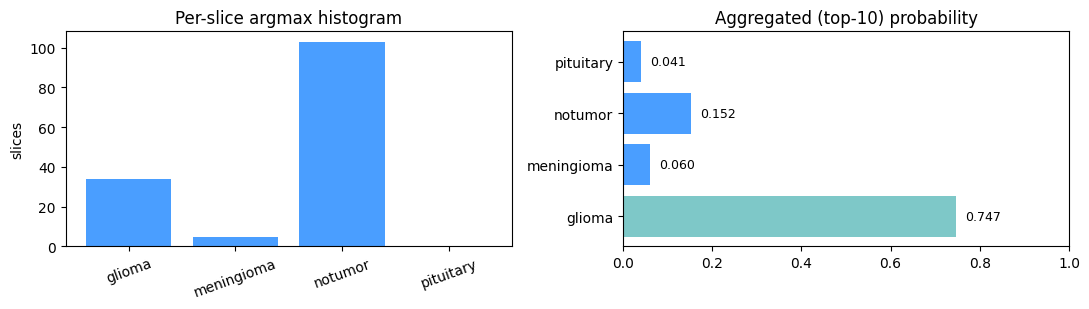

In [6]:
# Stage 0b — mask-free slice-wise classification over the volume.
if not CLS_AVAILABLE:
    print('Stage 0b skipped (no classifier checkpoint).')
else:
    print('=' * 78)
    print('  OUT-OF-DISTRIBUTION: classifier trained on pre-op 4-class JPEGs;')
    print('  MU-Glioma-Post is 100% glioma and POST-OPERATIVE. Demonstration only.')
    print('=' * 78)

    _classes = CLS_CFG_INFER['classes']
    _mod = CLS_CFG_INFER['modality']
    per_slice_probs, kept_z = [], []
    for z in range(Z):
        sl = minmax_norm_2d(patient[_mod][:, :, z])
        if float(np.abs(sl).sum()) < 1.0:          # skip empty slices
            continue
        u8 = (np.rot90(sl) * 255).astype(np.uint8)
        x = preprocess_cls(u8, CLS_CFG_INFER).to(DEVICE)
        with torch.no_grad():
            per_slice_probs.append(torch.softmax(cls_model(x), 1)[0].cpu().numpy())
        kept_z.append(z)

    P = np.stack(per_slice_probs)                   # [n_slices, 4]
    ni = _classes.index('notumor')

    # Naive mean is dominated by the many tumour-free superior/inferior slices and
    # would report 'notumor' for a glioma patient. Aggregate over the top-K most
    # tumour-looking slices instead. Both are reported so the difference is visible.
    p_naive = P.mean(0); p_naive = p_naive / p_naive.sum()
    K = min(int(CLS_CFG_INFER['topk']), len(P))
    order = np.argsort(-(1.0 - P[:, ni]))            # most tumour-evidence first
    p_vol = P[order[:K]].mean(0); p_vol = p_vol / p_vol.sum()

    cls_result = {
        'label': _classes[int(np.argmax(p_vol))],
        'confidence': float(np.max(p_vol)),
        'probabilities': {c: float(p_vol[i]) for i, c in enumerate(_classes)},
        'probabilities_naive_mean': {c: float(p_naive[i]) for i, c in enumerate(_classes)},
        'topk': K,
        'n_slices': int(len(P)),
        'rep_z': int(kept_z[int(order[0])]),
    }

    print(f"\nSlices scored: {len(P)}   aggregation: top-{K} tumour-evidence mean softmax")
    print(f"  top-{K} : " + '  '.join(f'{c}={p_vol[i]:.3f}' for i, c in enumerate(_classes)))
    print(f"  naive  : " + '  '.join(f'{c}={p_naive[i]:.3f}' for i, c in enumerate(_classes)))
    print(f"\n  -> {cls_result['label'].upper()}  ({cls_result['confidence']*100:.1f}% confidence)")
    if _classes[int(np.argmax(p_naive))] != cls_result['label']:
        print(f"  (note: the naive mean would have said "
              f"'{_classes[int(np.argmax(p_naive))]}' — that is the empty-slice bias)")

    # Per-slice argmax histogram + aggregated probabilities
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    counts = [int((P.argmax(1) == i).sum()) for i in range(len(_classes))]
    ax[0].bar(_classes, counts, color='#4a9eff')
    ax[0].set_title('Per-slice argmax histogram'); ax[0].set_ylabel('slices')
    ax[0].tick_params(axis='x', rotation=20)
    ax[1].barh(_classes, p_vol, color=['#7ec8c8' if i == int(np.argmax(p_vol)) else '#4a9eff'
                                       for i in range(len(_classes))])
    ax[1].set_xlim(0, 1); ax[1].set_title(f'Aggregated (top-{K}) probability')
    for i, v in enumerate(p_vol):
        ax[1].text(min(v + 0.02, 0.92), i, f'{v:.3f}', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

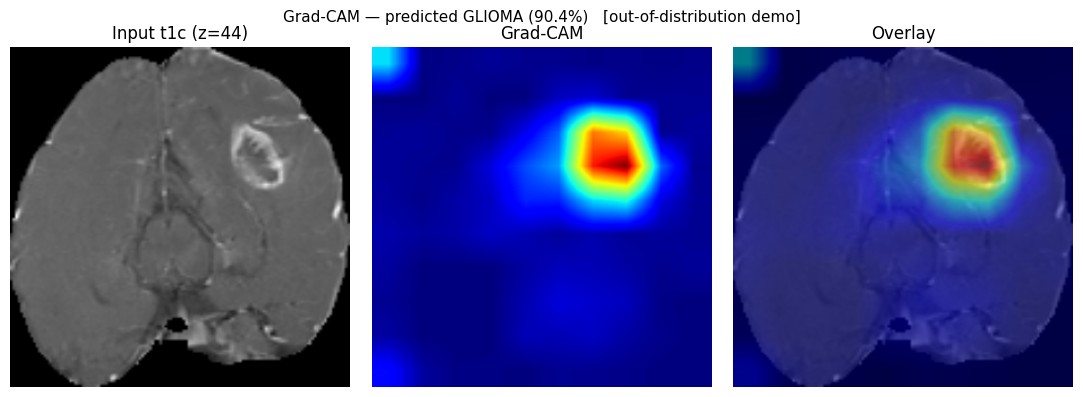

In [7]:
# Stage 0b — Grad-CAM: which pixels drove the prediction?
CLS_CAM_LAYER = 'backbone.features.8'   # final 1536-ch Conv2dNormActivation; 10×10 @ 300²

def get_cam_layer(model, key=CLS_CAM_LAYER):
    return dict(model.named_modules())[key]

def _disable_inplace(module):
    """Cheap insurance: in-place activations can interact badly with backward hooks
    on some torch builds. (Verified a no-op on torchvision 0.25 — gradients are
    identical either way — but it costs nothing and removes the failure mode.)"""
    for m in module.modules():
        if hasattr(m, 'inplace'):
            m.inplace = False

class ClsGradCAM:
    """Grad-CAM for a classifier — identical hook machinery to SegGradCAM
    (nnUnet.ipynb §13). Only the scalar objective differs: segmentation used
    (prob * pred_mask).sum(); here we use logits[0, class_idx]."""

    def __init__(self, model, target_layer):
        self.model = model
        self._acts = self._grads = None
        self._fwd = target_layer.register_forward_hook(self._save_act)
        self._bwd = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, _m, _i, out): self._acts = out.detach()
    def _save_grad(self, _m, _i, g):  self._grads = g[0].detach()

    def remove(self):
        self._fwd.remove(); self._bwd.remove()

    @torch.enable_grad()
    def __call__(self, image, class_idx=None):
        """image (1,3,H,W) → (cam H×W float32 in [0,1], class_idx, probs np[K])."""
        self.model.eval()
        self._acts = self._grads = None
        logits = self.model(image)
        probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[0, class_idx]              # raw logit — softmax couples the classes
        self.model.zero_grad(set_to_none=True)
        score.backward()
        if self._grads is None or self._acts is None:
            return np.zeros(image.shape[-2:], np.float32), class_idx, probs
        weights = self._grads.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((weights * self._acts).sum(dim=1)).squeeze(0).cpu().numpy()
        cam = cv2.resize(cam, (image.shape[3], image.shape[2]), interpolation=cv2.INTER_LINEAR)
        lo, hi = float(cam.min()), float(cam.max())
        if hi > lo:
            cam = (cam - lo) / (hi - lo)
        return cam.astype(np.float32), class_idx, probs


if not CLS_AVAILABLE or cls_result is None:
    print('Stage 0b Grad-CAM skipped (no classifier).')
else:
    _disable_inplace(cls_model)
    _cam = ClsGradCAM(cls_model, get_cam_layer(cls_model))
    _z = cls_result['rep_z']
    _sl = minmax_norm_2d(patient[CLS_CFG_INFER['modality']][:, :, _z])
    _u8 = (np.rot90(_sl) * 255).astype(np.uint8)
    _x = preprocess_cls(_u8, CLS_CFG_INFER).to(DEVICE)
    cam, ci, probs = _cam(_x)
    _cam.remove()

    # Degenerate-CAM guard: check the pre-normalization spread, not max()==0
    # (an untrained net gives max ~1e-5, which would false-positive on ==0).
    if not np.isfinite(cam).all() or float(cam.max()) - float(cam.min()) <= 0.0:
        print('[cam] WARNING: degenerate (flat) CAM — hooks may not have fired.')

    S = CLS_CFG_INFER['img_size']
    base = cv2.resize(crop_brain_region(_u8), (S, S), interpolation=cv2.INTER_LINEAR)
    heat = (plt.get_cmap('jet')(cam)[..., :3] * 255).astype(np.uint8)
    rgb = np.stack([base] * 3, -1)
    over = (0.45 * rgb + 0.55 * heat).astype(np.uint8)

    fig, ax = plt.subplots(1, 3, figsize=(11, 4))
    for a, im, t in zip(ax, [rgb, cam, over],
                        [f'Input t1c (z={_z})', 'Grad-CAM', 'Overlay']):
        a.imshow(im, cmap='jet' if im is cam else None); a.set_title(t); a.axis('off')
    fig.suptitle(f"Grad-CAM — predicted {CLS_CFG_INFER['classes'][ci].upper()} "
                 f"({probs[ci]*100:.1f}%)   [out-of-distribution demo]", fontsize=11)
    plt.tight_layout(); plt.show()

## Stage 1 — Tumor Segmentation (nnU-Net 2D)

Compact nnU-Net 2D (GroupNorm + LeakyReLU, deep supervision, ~0.7M params). The
checkpoint `best_nnunet2d.pth` is the **EMA** shadow weights — the training loop saves
the exponential-moving-average model as the deployed checkpoint — so loading it already
gives the EMA model (no extra step required).

At inference we reproduce the **exact deployment pipeline** from `nnUnet.ipynb`:
- **TTA** via `ttach.Compose([HorizontalFlip, VerticalFlip, Rotate90([0,90,180,270])])`
  — a Cartesian product of **16 augmentations** averaged per slice (`merge_mode='mean'`).
- **Post-processing**: morphological open/close → hole fill → largest connected component.

Deep-supervision heads are dropped in eval mode; a thin wrapper guarantees the TTA
wrapper only ever sees the single full-resolution output tensor.

In [8]:
def _num_groups(channels: int, target: int = 8) -> int:
    for g in range(min(target, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1


class ConvBlock(nn.Module):
    '''Two 3x3 convolutions with GroupNorm + LeakyReLU.'''
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(_num_groups(out_ch), out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(_num_groups(out_ch), out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class nnUNet2D(nn.Module):
    '''Compact U-Net with nnU-Net design choices (deep supervision in train mode).'''
    def __init__(self, in_channels=4, num_classes=1, deep_supervision=True, drop_rate=0.3):
        super().__init__()
        self.deep_supervision = deep_supervision
        feats = [16, 32, 64, 128, 128]

        self.enc1 = ConvBlock(in_channels, feats[0])
        self.down1 = nn.Conv2d(feats[0], feats[0], 2, stride=2, bias=False)
        self.enc_drop1 = nn.Dropout2d(drop_rate * 0.5)
        self.enc2 = ConvBlock(feats[0], feats[1])
        self.down2 = nn.Conv2d(feats[1], feats[1], 2, stride=2, bias=False)
        self.enc_drop2 = nn.Dropout2d(drop_rate * 0.5)
        self.enc3 = ConvBlock(feats[1], feats[2])
        self.down3 = nn.Conv2d(feats[2], feats[2], 2, stride=2, bias=False)
        self.enc_drop3 = nn.Dropout2d(drop_rate)
        self.enc4 = ConvBlock(feats[2], feats[3])
        self.down4 = nn.Conv2d(feats[3], feats[3], 2, stride=2, bias=False)
        self.enc_drop4 = nn.Dropout2d(drop_rate)

        self.bottleneck = ConvBlock(feats[3], feats[4])
        self.bn_drop = nn.Dropout2d(drop_rate)

        self.up4 = nn.ConvTranspose2d(feats[4], feats[3], 2, stride=2)
        self.dec4 = ConvBlock(feats[3] * 2, feats[3])
        self.drop4 = nn.Dropout2d(drop_rate)
        self.up3 = nn.ConvTranspose2d(feats[3], feats[2], 2, stride=2)
        self.dec3 = ConvBlock(feats[2] * 2, feats[2])
        self.drop3 = nn.Dropout2d(drop_rate)
        self.up2 = nn.ConvTranspose2d(feats[2], feats[1], 2, stride=2)
        self.dec2 = ConvBlock(feats[1] * 2, feats[1])
        self.drop2 = nn.Dropout2d(drop_rate * 0.5)
        self.up1 = nn.ConvTranspose2d(feats[1], feats[0], 2, stride=2)
        self.dec1 = ConvBlock(feats[0] * 2, feats[0])

        self.seg_out = nn.Conv2d(feats[0], num_classes, 1)
        if deep_supervision:
            self.ds3 = nn.Conv2d(feats[2], num_classes, 1)
            self.ds2 = nn.Conv2d(feats[1], num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.enc_drop1(self.down1(e1)))
        e3 = self.enc3(self.enc_drop2(self.down2(e2)))
        e4 = self.enc4(self.enc_drop3(self.down3(e3)))
        bn = self.bn_drop(self.bottleneck(self.enc_drop4(self.down4(e4))))
        d4 = self.drop4(self.dec4(torch.cat([self.up4(bn), e4], dim=1)))
        d3 = self.drop3(self.dec3(torch.cat([self.up3(d4), e3], dim=1)))
        d2 = self.drop2(self.dec2(torch.cat([self.up2(d3), e2], dim=1)))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        out = self.seg_out(d1)
        if self.training and self.deep_supervision:
            return out, self.ds2(d2), self.ds3(d3)
        return out


seg_model = nnUNet2D(in_channels=4, num_classes=1, deep_supervision=True).to(DEVICE)
seg_state = torch.load(CFG['seg_ckpt'], map_location=DEVICE)
if isinstance(seg_state, dict) and 'model_state_dict' in seg_state:
    seg_state = seg_state['model_state_dict']
seg_state = { (k[7:] if k.startswith('module.') else k): v for k, v in seg_state.items() }
seg_model.load_state_dict(seg_state)
seg_model.eval()
print(f'nnU-Net 2D loaded — {sum(p.numel() for p in seg_model.parameters()):,} params')


nnU-Net 2D loaded — 1,373,987 params


In [9]:
from scipy import ndimage
import ttach as tta_lib


def post_process(pred_prob: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    '''Morphological open/close -> hole fill -> largest connected component.'''
    b = (pred_prob > threshold).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    b = cv2.morphologyEx(b, cv2.MORPH_OPEN, k)
    b = cv2.morphologyEx(b, cv2.MORPH_CLOSE, k)
    b = ndimage.binary_fill_holes(b).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(b, connectivity=8)
    if n > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        b = (lab == largest).astype(np.uint8)
    return b


class _DSStripWrapper(nn.Module):
    '''Return only the full-resolution tensor so TTA wraps a single output.'''
    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, x):
        out = self.base(x)
        return out[0] if isinstance(out, (tuple, list)) else out


# Exact TTA used during training/eval in nnUnet.ipynb:
#   Compose builds the Cartesian PRODUCT  ->  2 (hflip) x 2 (vflip) x 4 (rot90) = 16 augs
TTA_TRANSFORMS = tta_lib.Compose([
    tta_lib.HorizontalFlip(),
    tta_lib.VerticalFlip(),
    tta_lib.Rotate90(angles=[0, 90, 180, 270]),
])
seg_tta = tta_lib.SegmentationTTAWrapper(
    _DSStripWrapper(seg_model).to(DEVICE), TTA_TRANSFORMS, merge_mode='mean')
print(f'TTA: {len(TTA_TRANSFORMS)} augmentations averaged per slice (merge_mode=mean)')


def dice_coef(a: np.ndarray, b: np.ndarray, eps: float = 1e-6) -> float:
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    return float((2 * inter + eps) / (a.sum() + b.sum() + eps))


sz = CFG['img_size']
pred_mask_vol = np.zeros((H, W, Z), dtype=np.float32)   # native-resolution binary mask
seg_dices = []

for z in range(Z):
    chans = [minmax_norm_2d(patient[m][:, :, z]) for m in ('t1n', 't1c', 't2w', 't2f')]
    img = np.stack(chans, axis=-1)                                   # [H,W,4]
    if float(np.abs(img).sum()) < 1.0:                              # skip empty slices
        continue
    img_rs = cv2.resize(img, (sz, sz), interpolation=cv2.INTER_LINEAR)
    x = torch.from_numpy(np.transpose(img_rs, (2, 0, 1))).unsqueeze(0).to(DEVICE)  # [1,4,sz,sz]
    with torch.no_grad():
        prob = torch.sigmoid(seg_tta(x)).squeeze().cpu().numpy().astype(np.float32)  # TTA-merged
    clean = post_process(prob, CFG['mask_threshold'])               # [sz,sz] binary
    pred_native = cv2.resize(clean.astype(np.float32), (W, H), interpolation=cv2.INTER_NEAREST)
    pred_mask_vol[:, :, z] = (pred_native > 0.5).astype(np.float32)

    gt = (patient['mask'][:, :, z] > 0)
    if gt.sum() > 0:
        seg_dices.append(dice_coef(pred_mask_vol[:, :, z], gt))

print(f'Predicted tumor voxels: {int(pred_mask_vol.sum()):,}')
print(f'Mean per-slice Dice (tumor slices): {np.mean(seg_dices):.4f}  over {len(seg_dices)} slices')


TTA: 16 augmentations averaged per slice (merge_mode=mean)
Predicted tumor voxels: 96,939
Mean per-slice Dice (tumor slices): 0.8023  over 68 slices


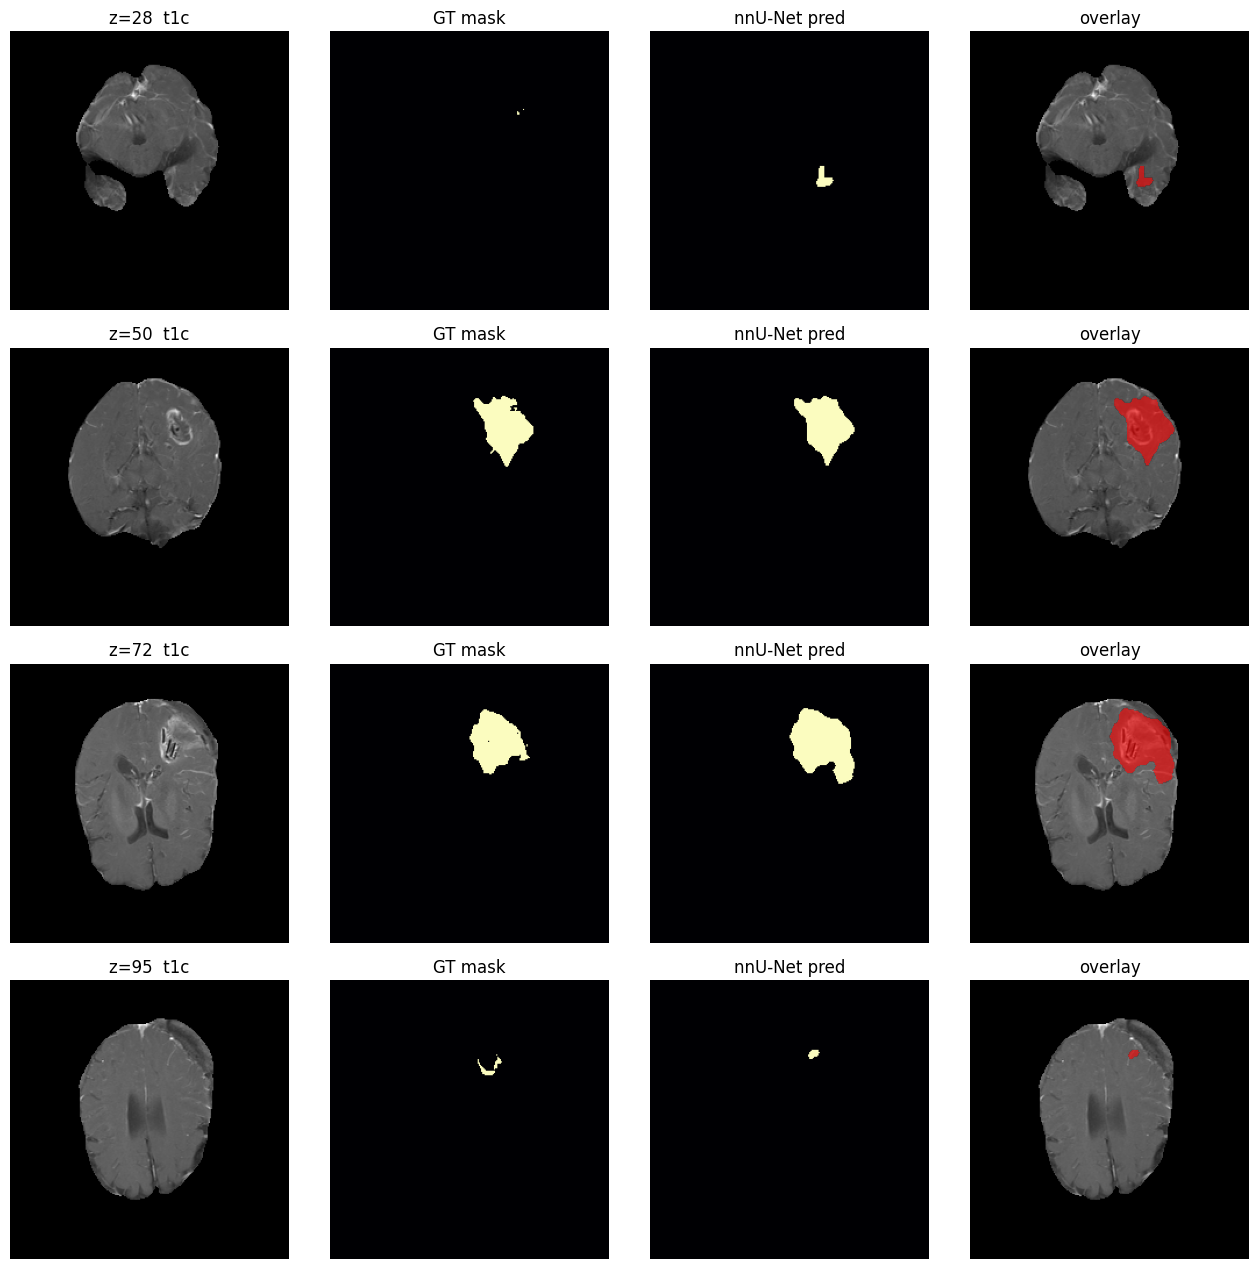

In [10]:
# Qualitative segmentation: input t1c, GT mask, predicted mask, overlay
tumor_zs = np.where((patient['mask'] > 0).sum(axis=(0, 1)) > 0)[0]
show_zs = (np.linspace(tumor_zs[0], tumor_zs[-1], 4).astype(int)
           if len(tumor_zs) else [Z // 2])

fig, ax = plt.subplots(len(show_zs), 4, figsize=(13, 3.2 * len(show_zs)))
ax = np.atleast_2d(ax)
for r, z in enumerate(show_zs):
    base = np.rot90(minmax_norm_2d(patient['t1c'][:, :, z]))
    gt = np.rot90((patient['mask'][:, :, z] > 0).astype(np.float32))
    pr = np.rot90(pred_mask_vol[:, :, z])
    ax[r, 0].imshow(base, cmap='gray'); ax[r, 0].set_title(f'z={z}  t1c')
    ax[r, 1].imshow(gt, cmap='magma'); ax[r, 1].set_title('GT mask')
    ax[r, 2].imshow(pr, cmap='magma'); ax[r, 2].set_title('nnU-Net pred')
    ax[r, 3].imshow(base, cmap='gray')
    ax[r, 3].imshow(np.ma.masked_where(pr < 0.5, pr), cmap='autumn', alpha=0.6)
    ax[r, 3].set_title('overlay')
    for c in range(4):
        ax[r, c].axis('off')
plt.tight_layout(); plt.show()


## Stage 2 — Sparse-to-Dense Reconstruction (Fast2p5D GAN generator)

The generator consumes a **5-channel, 5-slice** context window
`[t1n, t1c, t2w, t2f, mask_density]` and predicts the next `t1n` slice. Here the
`mask_density` channel is the **Stage-1 predicted mask** (not the ground truth), so the
two models are genuinely cascaded.

We simulate a low-dose acquisition (alternating known anchors) and reconstruct the full
volume with the **full production inference pipeline** ported verbatim from
`3d-recon-disc.ipynb`:

- **Bidirectional autoregressive** sweep (forward, then backward on the z-flipped volume)
- **Multi-scale** prediction at scales `1.0` + `0.85`, weighted `0.65 / 0.35`
- **TTA**: 4 modes (`none / hflip / vflip / hvflip`) averaged per slice
- **Distance-weighted fusion** of the forward/backward passes (nearest anchor wins)
- **Post-processing**: per-slice median filter (k=3) → Gaussian blur (σ=0.7) → unsharp masking (α=0.10)
- **Metrics**: PSNR / SSIM (`skimage`) on the predicted (non-anchor) slices

> This is ~`scales × tta_modes = 8` generator calls per predicted slice, twice
> (forward + backward) — substantially slower than a plain single pass, but it matches
> the README "Inference Pipeline" exactly.

In [11]:
class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetDecoder2D(nn.Module):
    def __init__(self, in_ch=128, out_ch=1):
        super().__init__()
        self.enc1 = ConvBlock2D(in_ch, 128)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = ConvBlock2D(128, 256)
        self.bottleneck = ConvBlock2D(256, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = ConvBlock2D(512, 256)
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = ConvBlock2D(256, 128)
        self.head = nn.Conv2d(128, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.head(d1))


class SliceCNN2D(nn.Module):
    def __init__(self, in_ch=5, out_ch=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 48, 3, padding=1, bias=False),
            nn.BatchNorm2d(48), nn.ReLU(inplace=True),
            nn.Conv2d(48, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Fast2p5D(nn.Module):
    '''Per-slice 2D encoder + depth attention + 2D decoder. In [B,5,5,H,W] -> [B,1,H,W].'''
    def __init__(self, in_ch=5, feat_ch=96, out_ch=1):
        super().__init__()
        self.slice_cnn = SliceCNN2D(in_ch, feat_ch)
        self.depth_attn = nn.Sequential(
            nn.Linear(feat_ch, feat_ch // 2), nn.ReLU(inplace=True),
            nn.Linear(feat_ch // 2, 1))
        self.decoder = UNetDecoder2D(feat_ch, out_ch)

    def forward(self, x):
        b, c, d, h, w = x.shape
        feats = torch.stack([self.slice_cnn(x[:, :, di]) for di in range(d)], dim=1)
        alpha = torch.softmax(self.depth_attn(feats.mean(dim=(3, 4))).squeeze(-1), dim=1)
        fused = (feats * alpha[:, :, None, None, None]).sum(dim=1)
        return self.decoder(fused)


G = Fast2p5D(in_ch=5, feat_ch=96, out_ch=1).to(DEVICE)
gan_ckpt = torch.load(CFG['gan_ckpt'], map_location=DEVICE, weights_only=False)
gan_state = gan_ckpt['model_state_dict'] if 'model_state_dict' in gan_ckpt else gan_ckpt
G.load_state_dict(gan_state)
G.eval()
print(f"Fast2p5D generator loaded (saved phase={gan_ckpt.get('phase')}, "
      f"epoch={gan_ckpt.get('epoch')}) — {sum(p.numel() for p in G.parameters()):,} params")


Fast2p5D generator loaded (saved phase=joint, epoch=5) — 7,603,186 params


In [12]:
from scipy.ndimage import median_filter, gaussian_filter
from skimage.metrics import peak_signal_noise_ratio as _psnr_fn
from skimage.metrics import structural_similarity as _ssim_fn

# Full-quality inference settings (match 3d-recon-disc.ipynb, cell "INFERENCE")
INFER_CFG = {
    'scales':             [1.0, 0.85],
    'scale_weights':      [0.65, 0.35],
    'tta_modes':          ['none', 'hflip', 'vflip', 'hvflip'],
    'post_median_k':      3,
    'post_gauss_sigma':   0.7,
    'post_unsharp_alpha': 0.10,
    'img_size':           CFG['img_size'],
    'context_depth':      5,
}
IMG = INFER_CFG['img_size']
CTX = INFER_CFG['context_depth']


def make_known_mask_half_alternating(z_count: int) -> np.ndarray:
    known = np.zeros(z_count, dtype=bool)
    known[::2] = True
    if not known.any():
        known[0] = True
    return known


def init_t1n_state_from_known(t1n_gt: np.ndarray, known_mask: np.ndarray) -> np.ndarray:
    h, w, z_count = t1n_gt.shape
    known_ids = np.where(known_mask)[0]
    if len(known_ids) == 0:
        raise ValueError('known_mask has no known slices')
    state = np.zeros_like(t1n_gt, dtype=np.float32)
    for z in range(z_count):
        nearest = z if known_mask[z] else int(known_ids[np.argmin(np.abs(known_ids - z))])
        state[:, :, z] = t1n_gt[:, :, nearest]
    return state


def build_context_slice(vols, t1n_state, known_mask, z_id, img_size, input_mode,
                        use_pred_for_all_channels=True):
    '''One [5,H,W] context frame: [t1n, t1c, t2w, t2f, mask].
    The mask channel uses vols['mask'] — the Stage-1 PREDICTED mask volume.'''
    z_max = vols['t1n'].shape[2] - 1
    z = int(np.clip(z_id, 0, z_max))
    rs = lambda a: cv2.resize(a, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    mask_base = rs((vols['mask'][:, :, z] > 0).astype(np.float32))

    if known_mask[z]:
        t1n_base = rs(minmax_norm_2d(vols['t1n'][:, :, z]))
        if input_mode == 't1n_mask':
            zero = np.zeros_like(t1n_base, dtype=np.float32)
            c_t1n, c_t1c, c_t2w, c_t2f, c_msk = t1n_base, zero, zero, zero, mask_base
        else:
            c_t1n = t1n_base
            c_t1c = rs(minmax_norm_2d(vols['t1c'][:, :, z]))
            c_t2w = rs(minmax_norm_2d(vols['t2w'][:, :, z]))
            c_t2f = rs(minmax_norm_2d(vols['t2f'][:, :, z]))
            c_msk = mask_base
    else:
        pred_base = rs(minmax_norm_2d(t1n_state[:, :, z]))
        if input_mode == 't1n_mask':
            zero = np.zeros_like(pred_base, dtype=np.float32)
            c_t1n, c_t1c, c_t2w, c_t2f, c_msk = pred_base, zero, zero, zero, mask_base
        elif use_pred_for_all_channels:
            c_t1n = c_t1c = c_t2w = c_t2f = c_msk = pred_base
        else:
            c_t1n = pred_base
            c_t1c = rs(minmax_norm_2d(vols['t1c'][:, :, z]))
            c_t2w = rs(minmax_norm_2d(vols['t2w'][:, :, z]))
            c_t2f = rs(minmax_norm_2d(vols['t2f'][:, :, z]))
            c_msk = mask_base

    return np.stack([c_t1n, c_t1c, c_t2w, c_t2f, c_msk], axis=0).astype(np.float32)  # [5,H,W]


def _tta(arr, mode):
    '''Flips are self-inverse; applied to context frames and predictions alike.'''
    if mode == 'none':  return arr
    if mode == 'hflip': return np.flip(arr, axis=-1).copy()
    if mode == 'vflip': return np.flip(arr, axis=-2).copy()
    return np.flip(np.flip(arr, axis=-1), axis=-2).copy()


@torch.no_grad()
def _predict_slice(model, ctx_frames):
    '''TTA x multi-scale single-slice prediction. ctx_frames: list of CTX [5,H,W] frames.'''
    model.eval()
    scale_acc = np.zeros((IMG, IMG), dtype=np.float32)
    for sc, sw in zip(INFER_CFG['scales'], INFER_CFG['scale_weights']):
        sc_size = max(32, int(round(IMG * sc)))
        sc_size = (sc_size // 4) * 4  # decoder needs spatial dims divisible by 4
        tta_acc = np.zeros((IMG, IMG), dtype=np.float32)
        for mode in INFER_CFG['tta_modes']:
            frames = []
            for ctx in ctx_frames:
                f = _tta(ctx, mode)
                if sc_size != IMG:
                    f = np.stack([cv2.resize(f[c], (sc_size, sc_size), interpolation=cv2.INTER_LINEAR)
                                  for c in range(f.shape[0])])
                frames.append(f)
            x = torch.from_numpy(np.stack(frames, axis=0).astype(np.float32)).unsqueeze(0).to(DEVICE)
            x = x.permute(0, 2, 1, 3, 4)        # [1,CTX,5,H,W] -> [1,5,CTX,H,W] = [B,C,D,H,W]
            pred = model(x).squeeze().cpu().numpy()
            pred = np.clip(pred, 0.0, 1.0)
            pred = _tta(pred, mode)             # undo flip
            if sc_size != IMG:
                pred = cv2.resize(pred, (IMG, IMG), interpolation=cv2.INTER_LINEAR)
            tta_acc += pred / len(INFER_CFG['tta_modes'])
        scale_acc += sw * tta_acc
    return scale_acc.astype(np.float32)


def _build_ctx(vols, state, known, z, mode):
    return [build_context_slice(vols, state, known, z - CTX + di, IMG, mode) for di in range(CTX)]


def reconstruct_full_volume_quality(model, vols, known_mask, input_mode='all5', verbose=True):
    '''Bidirectional autoregressive + multi-scale + TTA + distance-weighted fusion + post-proc.
    Mirrors the inference cell of 3d-recon-disc.ipynb. Returns img-size and native volumes.'''
    t1n_gt = vols['t1n']; H_v, W_v, Z = t1n_gt.shape

    # ── Forward autoregressive pass ─────────────────────────────────────────
    fwd = np.zeros((IMG, IMG, Z), dtype=np.float32)
    fwd_state = init_t1n_state_from_known(t1n_gt, known_mask)
    for z in range(Z):
        if known_mask[z] or z < CTX:
            fwd[:, :, z] = cv2.resize(minmax_norm_2d(t1n_gt[:, :, z]), (IMG, IMG), interpolation=cv2.INTER_LINEAR)
        else:
            pred = _predict_slice(model, _build_ctx(vols, fwd_state, known_mask, z, input_mode))
            fwd[:, :, z] = pred
            fwd_state[:, :, z] = cv2.resize(pred, (W_v, H_v), interpolation=cv2.INTER_LINEAR)
        if verbose and z % 25 == 0:
            print(f'  forward  z={z:3d}/{Z-1}', end='\r')

    # ── Backward autoregressive pass (z-flipped volume) ─────────────────────
    vols_flip = {k: vols[k][:, :, ::-1].copy() for k in vols}
    known_flip = known_mask[::-1].copy()
    state_flip = init_t1n_state_from_known(vols_flip['t1n'], known_flip)
    bwd_flip = np.zeros((IMG, IMG, Z), dtype=np.float32)
    for z in range(Z):
        if known_flip[z] or z < CTX:
            bwd_flip[:, :, z] = cv2.resize(minmax_norm_2d(vols_flip['t1n'][:, :, z]), (IMG, IMG), interpolation=cv2.INTER_LINEAR)
        else:
            pred = _predict_slice(model, _build_ctx(vols_flip, state_flip, known_flip, z, input_mode))
            bwd_flip[:, :, z] = pred
            state_flip[:, :, z] = cv2.resize(pred, (W_v, H_v), interpolation=cv2.INTER_LINEAR)
        if verbose and z % 25 == 0:
            print(f'  backward z={z:3d}/{Z-1}', end='\r')
    bwd = bwd_flip[:, :, ::-1].copy()

    # ── Distance-weighted fusion ────────────────────────────────────────────
    known_ids = np.where(known_mask)[0]
    fused = np.zeros((IMG, IMG, Z), dtype=np.float32)
    for z in range(Z):
        if known_mask[z]:
            fused[:, :, z] = fwd[:, :, z]; continue
        prev = known_ids[known_ids <= z]; nxt = known_ids[known_ids >= z]
        w_f = 1.0 / (z - prev[-1] + 1) if len(prev) else 0.0
        w_b = 1.0 / (nxt[0] - z + 1) if len(nxt) else 0.0
        tot = w_f + w_b
        fused[:, :, z] = (0.5 * (fwd[:, :, z] + bwd[:, :, z]) if tot < 1e-12
                          else (w_f * fwd[:, :, z] + w_b * bwd[:, :, z]) / tot)

    # ── Post-processing (median -> Gaussian -> unsharp) ─────────────────────
    K, SG, UA = INFER_CFG['post_median_k'], INFER_CFG['post_gauss_sigma'], INFER_CFG['post_unsharp_alpha']
    post = np.empty_like(fused)
    for z in range(Z):
        sl = median_filter(fused[:, :, z], size=K)
        sl = sl + UA * (sl - gaussian_filter(sl, sigma=SG))
        post[:, :, z] = np.clip(sl, 0.0, 1.0)

    # ── Native-resolution volume ────────────────────────────────────────────
    native = np.stack([cv2.resize(post[:, :, z], (W_v, H_v), interpolation=cv2.INTER_LINEAR)
                       for z in range(Z)], axis=-1)
    if verbose:
        print(' ' * 40, end='\r')
    return {'fwd': fwd, 'bwd': bwd, 'fused': fused, 'post': post, 'native': native}


def recon_metrics(vols, post, known_mask):
    '''PSNR / SSIM on predicted (non-anchor) slices, at IMG resolution — matches disc.'''
    import warnings
    Z = vols['t1n'].shape[2]
    gt_img = np.stack([cv2.resize(minmax_norm_2d(vols['t1n'][:, :, z]), (IMG, IMG), interpolation=cv2.INTER_LINEAR)
                       for z in range(Z)], axis=-1)
    ps, ss = [], []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for z in range(Z):
            if known_mask[z]:
                continue
            ps.append(_psnr_fn(gt_img[:, :, z], post[:, :, z], data_range=1.0))
            ss.append(_ssim_fn(gt_img[:, :, z], post[:, :, z], data_range=1.0))
    return {'psnr_unknown': float(np.mean(ps)) if ps else float('nan'),
            'ssim_unknown': float(np.mean(ss)) if ss else float('nan'),
            'n_pred': len(ps)}


In [13]:
# Reconstruction inputs: GT modalities + Stage-1 PREDICTED mask as the density channel
vols_recon = {m: patient[m].astype(np.float32) for m in ('t1n', 't1c', 't2w', 't2f')}
vols_recon['mask'] = pred_mask_vol     # <-- cascade: Stage-1 output feeds Stage-2

# Sparse low-dose simulation: keep every other slice as a known anchor
known_mask = make_known_mask_half_alternating(Z)
print(f'Known (anchor) slices: {int(known_mask.sum())} / {Z} '
      f'({100*known_mask.mean():.0f}%)  — reconstructing the rest')
print(f"Full-quality inference: scales={INFER_CFG['scales']}, "
      f"TTA={len(INFER_CFG['tta_modes'])} modes, bidirectional + post-proc")
print('(this is the slow path — ~8 generator calls / predicted slice, x2 directions)\n')

recon = reconstruct_full_volume_quality(G, vols_recon, known_mask, input_mode='all5')
metrics = recon_metrics(vols_recon, recon['post'], known_mask)
print('Reconstruction quality on predicted (non-anchor) slices:')
print(f"  PSNR = {metrics['psnr_unknown']:.2f} dB | SSIM = {metrics['ssim_unknown']:.4f} "
      f"  ({metrics['n_pred']} predicted slices)")


Known (anchor) slices: 78 / 155 (50%)  — reconstructing the rest
Full-quality inference: scales=[1.0, 0.85], TTA=4 modes, bidirectional + post-proc
(this is the slow path — ~8 generator calls / predicted slice, x2 directions)

Reconstruction quality on predicted (non-anchor) slices:
  PSNR = 27.57 dB | SSIM = 0.9058   (77 predicted slices)


Saved reconstruction GIF: /kaggle/working/full_pipeline/PatientID_0003_Timepoint_1_recon.gif


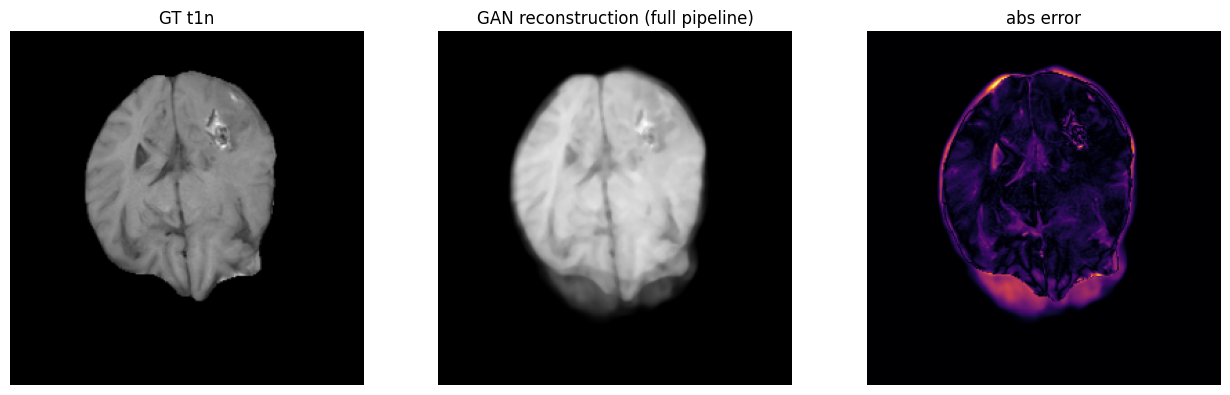

In [14]:
# GIF of the reconstructed volume + tumor-slice comparison
def to_u8(img):
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)

post = recon['post']                                  # [IMG,IMG,Z] in [0,1]
gt_img = np.stack([cv2.resize(minmax_norm_2d(patient['t1n'][:, :, z]), (IMG, IMG),
                              interpolation=cv2.INTER_LINEAR) for z in range(Z)], axis=-1)

frames = []
for z in range(Z):
    gt_u8 = to_u8(np.rot90(gt_img[:, :, z]))
    pr_u8 = to_u8(np.rot90(post[:, :, z]))
    pair = np.concatenate([gt_u8, pr_u8], axis=1)
    rgb = np.ascontiguousarray(np.stack([pair] * 3, axis=-1), dtype=np.uint8)
    tag = 'anchor' if known_mask[z] else 'predicted'
    cv2.putText(rgb, f'GT | recon ({tag}) z={z}', (8, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2, cv2.LINE_AA)
    frames.append(rgb)

gif_path = CFG['out_dir'] / f"{CFG['patient']}_{CFG['timepoint']}_recon.gif"
imageio.mimsave(gif_path, frames, fps=CFG['gif_fps'], loop=0)
print('Saved reconstruction GIF:', gif_path)

zc = z_tumor
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(np.rot90(gt_img[:, :, zc]), cmap='gray'); ax[0].set_title('GT t1n')
ax[1].imshow(np.rot90(post[:, :, zc]), cmap='gray'); ax[1].set_title('GAN reconstruction (full pipeline)')
ax[2].imshow(np.rot90(np.abs(gt_img[:, :, zc] - post[:, :, zc])), cmap='inferno'); ax[2].set_title('abs error')
for a in ax:
    a.axis('off')
plt.tight_layout(); plt.show()


## Stage 3 — Tumor Growth Prediction (Inverse Fisher–KPP PINN)

The PINN was fit as an inverse problem, recovering patient-specific growth parameters
`D_wm, D_gm, ρ` from sparse tumor-density observations. We load the trained checkpoint
with its self-contained `load_pinn()` helper, report the recovered parameters, and roll
the dynamics **forward in time** over the normalized domain to predict tumor-density
evolution `u(x, y, t)`, with MC-Dropout uncertainty.

> In deployment the observed density field driving the inverse fit comes from the
> segmentation masks (Stage 1) across timepoints; here we load the pre-fit model and
> forward-simulate.

In [15]:
import math
from dataclasses import dataclass
from typing import Tuple


@dataclass
class PINNConfig:
    brats_root: str = ''; brats_case_id: str = ''
    brats_slice_axis: int = 2; brats_slice_selection: str = 'tumor_centroid'
    brats_target_grid: int = 128; brats_mm_per_vox: float = 1.0
    seg_label_density: Tuple = ((1, 1.0), (2, 0.4), (3, 0.9), (4, 0.0))
    seg_density_smooth_sigma: float = 1.5; assumed_single_session_day: float = 200.0
    Lx: float = 100.0; Ly: float = 100.0; T: float = 250.0
    x0: float = 50.0; y0: float = 50.0; sigma0: float = 5.0
    gm_radius: float = 30.0; gm_center: Tuple = (50.0, 50.0)
    D_wm_true: float = 0.25; D_gm_true: float = 0.025; rho_true: float = 0.012
    fd_nx: int = 101; fd_ny: int = 101; fd_dt: float = 0.5
    fd_snapshot_times: Tuple = (50.0, 100.0, 200.0, 250.0)
    obs_times: Tuple = (25.0, 75.0, 125.0, 175.0, 225.0, 250.0)
    n_obs_total: int = 2000; obs_noise_std: float = 0.05
    T_pred: float = 250.0; heldout_fraction: float = 0.15
    hidden_layers: int = 6; hidden_width: int = 128; dropout_p: float = 0.05
    fourier_num_features: int = 32; fourier_sigma: float = 3.0; use_sigmoid_output: bool = True
    log_D_wm_prior_mean: float = math.log(0.3); log_D_wm_prior_std: float = 0.4
    log_D_gm_prior_mean: float = math.log(0.03); log_D_gm_prior_std: float = 0.4
    log_rho_prior_mean: float = math.log(0.01); log_rho_prior_std: float = 0.4
    init_param_noise: float = 0.15
    N_f: int = 20000; N_ic: int = 2000; N_bc: int = 1000
    rar_every: int = 500; rar_fraction: float = 0.20
    rar_candidate_mult: int = 5; rar_top_fraction: float = 0.20
    lambda_init: Tuple = (10.0, 50.0, 5.0, 500.0, 0.0, 0.0)
    adaptive_every: int = 1000; adaptive_alpha: float = 0.9
    phase1_iters: int = 3000; phase1_lr: float = 1e-3
    phase2_iters: int = 30000; phase2_lr: float = 5e-4
    phase3_iters: int = 2000; grad_clip_norm: float = 1.0
    cosine_T0: int = 5000; cosine_Tmult: int = 2
    curriculum_every: int = 2000; curriculum_start_frac: float = 0.25; curriculum_growth: float = 1.35
    mcd_samples: int = 200; ensemble_size: int = 5; laplace_samples: int = 1000
    dice_threshold: float = 0.25; eval_grid: int = 101; log_every: int = 200; quick_mode: bool = False

    def __post_init__(self):
        if self.quick_mode:
            self.phase1_iters = 1000; self.phase2_iters = 3000; self.phase3_iters = 300
            self.N_f = 4000; self.mcd_samples = 50; self.ensemble_size = 2; self.laplace_samples = 200


class FourierFeatures(nn.Module):
    def __init__(self, in_dim, num_features, sigma, seed=0):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.register_buffer('B', torch.randn(in_dim, num_features, generator=g) * sigma)

    def forward(self, x):
        proj = 2 * math.pi * x @ self.B
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)


class TanhSlopeLinear(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out)
        nn.init.xavier_uniform_(self.lin.weight); nn.init.zeros_(self.lin.bias)
        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        return torch.tanh(self.alpha * self.lin(x))


class TumorPINN(nn.Module):
    def __init__(self, cfg, wm_mask_np=None, seed=SEED):
        super().__init__()
        self.cfg = cfg
        torch.manual_seed(seed)
        self.ff = FourierFeatures(3, cfg.fourier_num_features, cfg.fourier_sigma, seed=seed)
        d = 2 * cfg.fourier_num_features; layers = []
        for _ in range(cfg.hidden_layers):
            layers.append(TanhSlopeLinear(d, cfg.hidden_width))
            if cfg.dropout_p > 0:
                layers.append(nn.Dropout(cfg.dropout_p))
            d = cfg.hidden_width
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d, 1)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)

        def _init(mu):
            return nn.Parameter(torch.tensor(
                mu + cfg.init_param_noise * (2 * torch.rand(1).item() - 1), dtype=DTYPE))
        self.log_D_wm = _init(cfg.log_D_wm_prior_mean)
        self.log_D_gm = _init(cfg.log_D_gm_prior_mean)
        self.log_rho = _init(cfg.log_rho_prior_mean)
        if wm_mask_np is not None:
            self.register_buffer('wm_mask', torch.tensor(wm_mask_np, dtype=DTYPE))
        else:
            self.register_buffer('wm_mask', torch.empty(0))

    def physical_params(self):
        return torch.exp(self.log_D_wm), torch.exp(self.log_D_gm), torch.exp(self.log_rho)

    def forward(self, x, y, t):
        xn = 2 * x / self.cfg.Lx - 1; yn = 2 * y / self.cfg.Ly - 1; tn = 2 * t / self.cfg.T - 1
        h = self.ff(torch.cat([xn, yn, tn], dim=-1))
        h = self.body(h); out = self.head(h)
        return torch.sigmoid(out) if self.cfg.use_sigmoid_output else out


def load_pinn(path, device=DEVICE):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    cfg_l = PINNConfig(**ckpt['config'])
    net = TumorPINN(cfg_l, wm_mask_np=ckpt.get('wm_mask')).to(device)
    net.load_state_dict(ckpt['model_state'])
    net.eval()
    return net, cfg_l, ckpt


pinn, pinn_cfg, pinn_ckpt = load_pinn(CFG['pinn_ckpt'])
D_wm, D_gm, rho = (float(v) for v in pinn.physical_params())
print('PINN loaded. Recovered patient-specific growth parameters:')
print(f'  D_wm (white matter diffusion): {D_wm:.4e}  [mm^2 / day]')
print(f'  D_gm (gray matter diffusion) : {D_gm:.4e}  [mm^2 / day]')
print(f'  rho  (proliferation rate)    : {rho:.4e}  [1 / day]')
print(f'  deep ensemble members        : {len(pinn_ckpt["ensemble_state"])}')
print(f'  checkpoint saved at          : {pinn_ckpt.get("saved_at")}')


PINN loaded. Recovered patient-specific growth parameters:
  D_wm (white matter diffusion): 2.6740e-06  [mm^2 / day]
  D_gm (gray matter diffusion) : 3.4566e-04  [mm^2 / day]
  rho  (proliferation rate)    : 1.2364e-04  [1 / day]
  deep ensemble members        : 5
  checkpoint saved at          : 2026-05-18 14:50:57


/tmp/ipykernel_22/1851082733.py:116: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  D_wm, D_gm, rho = (float(v) for v in pinn.physical_params())


In [16]:
# Forward growth prediction: evaluate u(x, y, t) on a grid over a time sweep
@torch.no_grad()
def eval_grid(net, cfg, t_val, n=101):
    xs = np.linspace(0, cfg.Lx, n); ys = np.linspace(0, cfg.Ly, n)
    X, Y = np.meshgrid(xs, ys, indexing='xy')
    fx = torch.tensor(X.reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    fy = torch.tensor(Y.reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    ft = torch.full_like(fx, float(t_val))
    u = net(fx, fy, ft).cpu().numpy().reshape(n, n)
    return X, Y, u


def mc_dropout_field(net, cfg, t_val, M=50, n=101):
    xs = np.linspace(0, cfg.Lx, n); ys = np.linspace(0, cfg.Ly, n)
    X, Y = np.meshgrid(xs, ys, indexing='xy')
    fx = torch.tensor(X.reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    fy = torch.tensor(Y.reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    ft = torch.full_like(fx, float(t_val))
    net.train()
    preds = []
    with torch.no_grad():
        for _ in range(M):
            preds.append(net(fx, fy, ft).cpu().numpy().reshape(n, n))
    net.eval()
    preds = np.stack(preds, 0)
    return preds.mean(0), preds.std(0)


t_grid = np.linspace(0.0, pinn_cfg.T_pred, 8)
fields = [eval_grid(pinn, pinn_cfg, t, n=pinn_cfg.eval_grid)[2] for t in t_grid]
vmax = float(max(f.max() for f in fields)) or 1.0

print('Predicted normalized tumor burden over time:')
for t, f in zip(t_grid, fields):
    print(f'  t={t:6.1f} d   mean u = {float(f.mean()):.4f}   max u = {float(f.max()):.4f}')


Predicted normalized tumor burden over time:
  t=   0.0 d   mean u = 0.0142   max u = 0.9695
  t=  35.7 d   mean u = 0.0053   max u = 0.1129
  t=  71.4 d   mean u = 0.0049   max u = 0.0600
  t= 107.1 d   mean u = 0.0052   max u = 0.0538
  t= 142.9 d   mean u = 0.0053   max u = 0.0599
  t= 178.6 d   mean u = 0.0051   max u = 0.0605
  t= 214.3 d   mean u = 0.0052   max u = 0.0544
  t= 250.0 d   mean u = 0.0180   max u = 0.9773


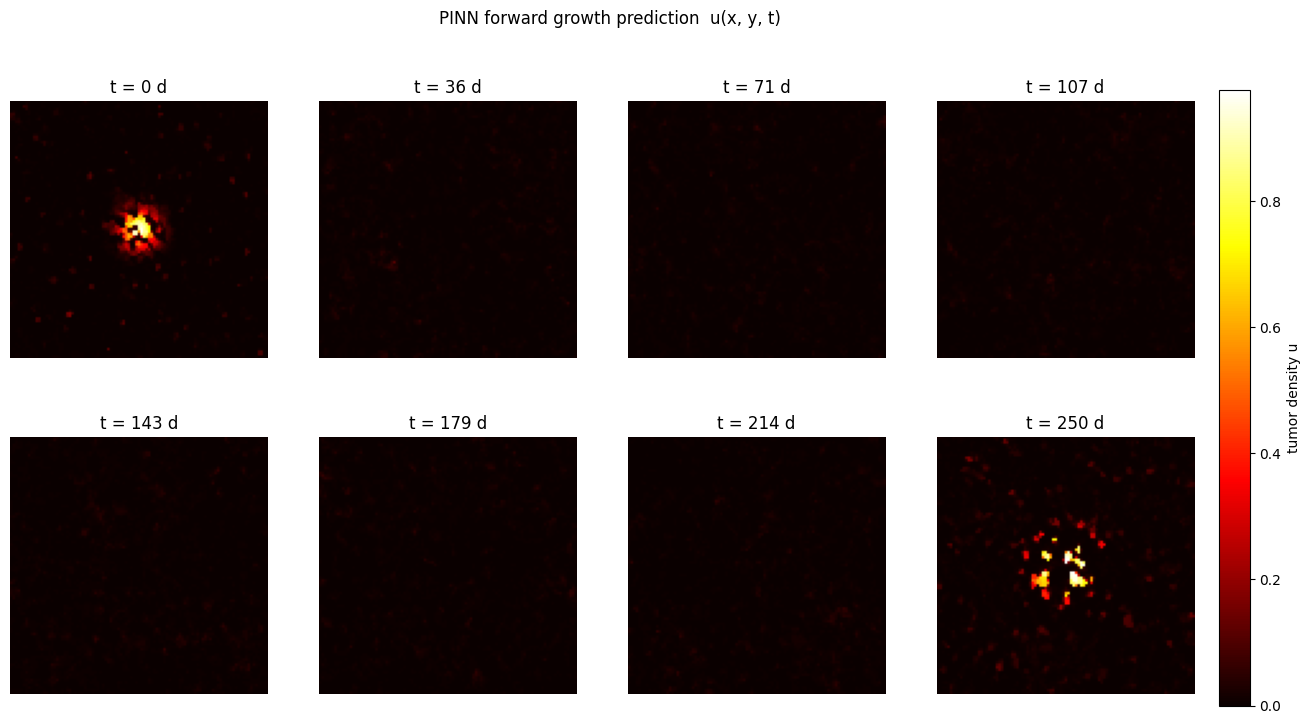

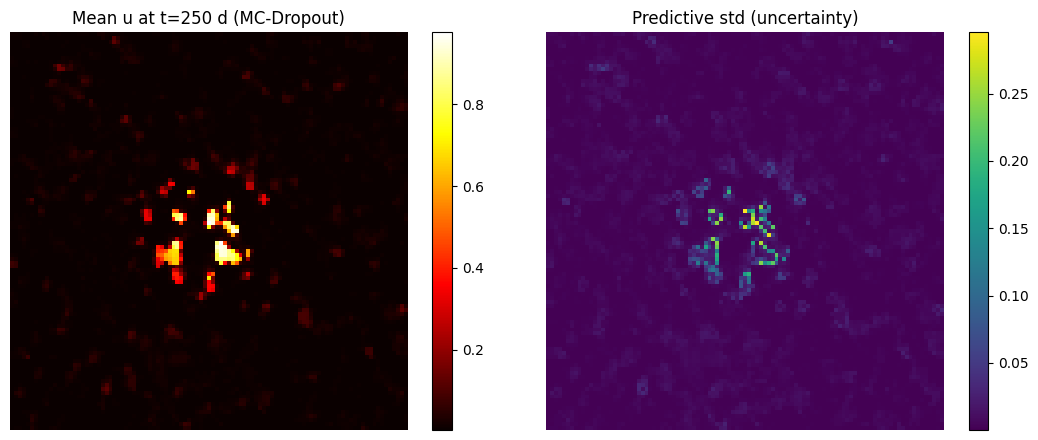

In [17]:
# Growth snapshots + uncertainty at the prediction horizon
fig, ax = plt.subplots(2, 4, figsize=(16, 8))
for i, (t, f) in enumerate(zip(t_grid, fields)):
    a = ax.flat[i]
    im = a.imshow(f, origin='lower', cmap='hot', vmin=0, vmax=vmax,
                  extent=[0, pinn_cfg.Lx, 0, pinn_cfg.Ly])
    a.set_title(f't = {t:.0f} d'); a.axis('off')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='tumor density u')
fig.suptitle('PINN forward growth prediction  u(x, y, t)', y=0.98)
plt.show()

u_mean, u_std = mc_dropout_field(pinn, pinn_cfg, pinn_cfg.T_pred, M=50, n=pinn_cfg.eval_grid)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = ax[0].imshow(u_mean, origin='lower', cmap='hot',
                   extent=[0, pinn_cfg.Lx, 0, pinn_cfg.Ly])
ax[0].set_title(f'Mean u at t={pinn_cfg.T_pred:.0f} d (MC-Dropout)'); ax[0].axis('off')
fig.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(u_std, origin='lower', cmap='viridis',
                   extent=[0, pinn_cfg.Lx, 0, pinn_cfg.Ly])
ax[1].set_title('Predictive std (uncertainty)'); ax[1].axis('off')
fig.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()


In [18]:
# Export the growth animation as a GIF
pinn_gif = CFG['out_dir'] / 'pinn_growth.gif'
g_frames = []
t_anim = np.linspace(0.0, pinn_cfg.T_pred, 24)
for t in t_anim:
    _, _, f = eval_grid(pinn, pinn_cfg, t, n=pinn_cfg.eval_grid)
    u8 = (np.clip(f / max(vmax, 1e-8), 0, 1) * 255).astype(np.uint8)
    rgb = cv2.applyColorMap(np.flipud(u8), cv2.COLORMAP_HOT)
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (256, 256), interpolation=cv2.INTER_NEAREST)
    rgb = np.ascontiguousarray(rgb, dtype=np.uint8)
    cv2.putText(rgb, f't={t:.0f}d', (10, 24), cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (255, 255, 255), 2, cv2.LINE_AA)
    g_frames.append(rgb)
imageio.mimsave(pinn_gif, g_frames, fps=CFG['gif_fps'], loop=0)
print('Saved PINN growth GIF:', pinn_gif)


Saved PINN growth GIF: /kaggle/working/full_pipeline/pinn_growth.gif


## Stage 4 — Predictive Evolution (the full closed-loop pipeline)

The complete cascade: **detect → evolve → re-detect → reconstruct → compare**.

1. **nnU-Net** tumour mask (Stage 1) seeds the growth model.
2. **PINN-recovered dynamics** drive a forward **anatomy-aware Fisher–KPP PDE**
   (`uₜ = ∇·(D(x)∇u) + ρ·u(1−u)`): diffusion `D` is high in white matter, ~0 in
   CSF/ventricles and outside the brain (no-flux boundary), with an optional
   contralateral barrier so the tumour stays in its hemisphere. `D_scale` and
   `rho_scale` are tuned **separately** (front speed ≈ `2√(D·ρ)`) for compact,
   front-driven growth instead of a uniform fill.
3. The evolved density is composited into all 4 modalities with a **heterogeneous
   tumour appearance** — necrotic core, enhancing rim at the growth front, edema halo —
   keeping some underlying anatomy (`blend_alpha`).
4. **nnU-Net re-segments** the evolved slices → the mask that conditions the GAN.
5. The **GAN** reconstructs the full evolved volume.
6. Outputs: a **3-panel** animation — initial (recon) · evolved (recon) · growth overlay —
   plus a **time-lapse** at the centroid slice. The two reconstruction panels are
   **de-flickered** (one global contrast window + gentle z-smoothing, `DISP`), and the
   overlay is drawn on the **reconstructed** slice (cyan = current tumour, red = predicted
   new growth) — no ground truth is shown. All carry tumour-volume (mL) readouts.

> The recovered parameters are amplified for a visible demo. Tune `GROWTH_CFG`
> (`rho_scale`, `D_scale`, `horizon_days`, `blend_alpha`) for faster/slower or
> subtler/stronger growth; set both scales to `1.0` and `horizon_days=250` for the
> physically faithful version. A single intensity-derived diffusivity proxy is used since
> no patient white/gray-matter map is available.

In [19]:
# Stage 4 setup — anatomy-aware Fisher–KPP evolution + realistic tumour appearance
GROWTH_CFG = {
    'grid':              128,      # FK simulation grid per slice
    'horizon_days':      180.0,    # how far into the future to evolve
    'rho_scale':         40.0,     # proliferation amplification  (compact growth)
    'D_scale':           150.0,    # diffusion amplification      (front travel)
    'seed_smooth_sigma': 1.5,      # smooth the binary mask into a density seed
    'brain_thr':         0.05,     # t1n > thr defines the brain (diffusion domain)
    'csf_thr':           0.18,     # below this (in brain) ~ CSF/ventricle -> low diffusion
    'wm_level':          0.55,     # t1n level treated as white matter -> max diffusion
    'midline_barrier':   True,     # confine growth to the tumour's hemisphere
    'barrier_margin':    10,       # px past midline kept open
    'blend_alpha':       0.75,     # keep some underlying anatomy (1.0 = fully overwrite)
    'render_ease':       0.8,      # composite with u**ease (lifts small densities)
    'evo_thr':           0.25,     # density counted as 'tumour' (matches PINN dice threshold)
    'snapshots':         [0, 45, 90, 135, 180],   # days saved for the growth time-lapse
}

# Recovered dynamics are tiny; apply the recovered REGIME amplified (separately for D and rho).
# Fisher front speed ~ 2*sqrt(D*rho): D_scale controls spread, rho_scale controls density.
D_max = float(max(D_wm, D_gm)) * GROWTH_CFG['D_scale']
rho_eff = float(rho) * GROWTH_CFG['rho_scale']
print(f"FK dynamics  D_max={D_max:.4e} (xD_scale {GROWTH_CFG['D_scale']:.0f}) | "
      f"rho_eff={rho_eff:.4e}/day (xrho_scale {GROWTH_CFG['rho_scale']:.0f}) | "
      f"horizon={GROWTH_CFG['horizon_days']:.0f} d | "
      f"front~{2*np.sqrt(D_max*rho_eff)*GROWTH_CFG['horizon_days']:.1f} px")

# Voxel volume for quantitative (mL) readouts
try:
    _vox = nib.load(str(find_modality_file(demo_tp, 't1n'))).header.get_zooms()[:3]
    VOX = tuple(float(v) for v in _vox)
    VOXEL_MM3 = float(VOX[0] * VOX[1] * VOX[2])
except Exception:
    VOX, VOXEL_MM3 = (1.0, 1.0, 1.0), 1.0
print(f'Voxel spacing (mm): {tuple(round(v, 2) for v in VOX)}  ->  {VOXEL_MM3:.3f} mm^3/voxel')

# Per-modality tumour appearance (normalized): necrotic core / enhancing rim / edema halo
APPEAR = {
    't1n': {'core': 0.35, 'rim': 0.55, 'edema': 0.45},   # iso/hypo
    't1c': {'core': 0.25, 'rim': 0.95, 'edema': 0.50},   # dark necrosis, bright enhancing rim
    't2w': {'core': 0.70, 'rim': 0.75, 'edema': 0.80},
    't2f': {'core': 0.65, 'rim': 0.80, 'edema': 0.92},   # FLAIR-bright edema
}


def build_D_field(t1n_norm_grid, seed_grid):
    '''Anatomy-aware diffusivity: ~0 in CSF/outside brain, max in white matter, with an
       optional contralateral barrier so the tumour stays in its hemisphere.'''
    brain = (t1n_norm_grid > GROWTH_CFG['brain_thr']).astype(np.float32)
    csf, wm = GROWTH_CFG['csf_thr'], GROWTH_CFG['wm_level']
    dnorm = np.clip((t1n_norm_grid - csf) / max(wm - csf, 1e-6), 0.0, 1.0)
    Dfield = brain * (0.05 + 0.95 * dnorm) * D_max          # 5%..100% of D_max inside brain
    if GROWTH_CFG['midline_barrier'] and seed_grid.max() > 0:
        ys, xs = np.where(seed_grid > 0.5 * seed_grid.max())
        cx = int(xs.mean()); mid = t1n_norm_grid.shape[1] // 2; m = GROWTH_CFG['barrier_margin']
        if cx < mid:
            Dfield[:, mid + m:] *= 0.02
        else:
            Dfield[:, :mid - m] *= 0.02
    return Dfield.astype(np.float32)


def fk_evolve_2d(u0, D_field, rho_eff, horizon, dx=1.0, max_steps=3000, snapshots=None):
    '''Forward heterogeneous Fisher-KPP (flux form, no-flux at brain/D=0 boundaries):

        u_t = div(D grad u) + rho * u (1 - u)

    Face diffusivities use the neighbour average and are zeroed across the brain boundary
    (proper Neumann no-flux). dt is auto-set for stability. Returns the final field, or
    {t: u_t} when `snapshots` (days) is given.'''
    active = (D_field > 0).astype(np.float32)
    Dmx = float(D_field.max())
    dt = 0.2 * dx * dx / max(Dmx, 1e-12)
    n_steps = int(np.clip(np.ceil(horizon / dt), 1, max_steps))
    dt = horizon / n_steps
    u = (u0 * active).astype(np.float32)
    Dxp = 0.5 * (D_field + np.roll(D_field, -1, 1)) * np.roll(active, -1, 1)
    Dxm = 0.5 * (D_field + np.roll(D_field,  1, 1)) * np.roll(active,  1, 1)
    Dyp = 0.5 * (D_field + np.roll(D_field, -1, 0)) * np.roll(active, -1, 0)
    Dym = 0.5 * (D_field + np.roll(D_field,  1, 0)) * np.roll(active,  1, 0)
    want = sorted(snapshots) if snapshots else []
    snaps = {}; si = 0
    if want and want[0] <= 0:
        snaps[want[0]] = u.copy(); si = 1
    for step in range(1, n_steps + 1):
        flux = (Dxp * (np.roll(u, -1, 1) - u) - Dxm * (u - np.roll(u, 1, 1)) +
                Dyp * (np.roll(u, -1, 0) - u) - Dym * (u - np.roll(u, 1, 0))) / (dx * dx)
        u = np.clip(u + dt * (flux + rho_eff * u * (1.0 - u)), 0.0, 1.0) * active
        t_now = step * dt
        while si < len(want) and t_now >= want[si] - 1e-9:
            snaps[want[si]] = u.copy(); si += 1
    if want:
        snaps[horizon] = u.copy()
        return snaps
    return u


def composite_tumor(u, base, mod, alpha):
    '''Heterogeneous tumour look: necrotic core + enhancing rim (front) + edema halo,
       blended over the underlying anatomy (alpha < 1 keeps some structure).'''
    gy, gx = np.gradient(u)
    grad = np.hypot(gx, gy); grad = grad / (grad.max() + 1e-8)
    core = np.clip((u - 0.55) / 0.35, 0, 1)             # dense centre
    rim = np.clip(grad * 1.5, 0, 1) * (u > 0.15)        # active front
    edema = np.clip(u, 0, 1) * (1.0 - core)             # outer halo
    look = APPEAR[mod]
    tumor = np.clip(core * look['core'] + rim * look['rim'] + edema * look['edema'], 0, 1)
    presence = np.clip(u + 0.6 * rim, 0, 1)
    a = alpha * presence
    return np.clip(base * (1 - a) + tumor * a, 0, 1)


print('Anatomy-aware FK solver + heterogeneous compositing ready.')


FK dynamics  D_max=5.1849e-02 (xD_scale 150) | rho_eff=4.9458e-03/day (xrho_scale 40) | horizon=180 d | front~5.8 px
Voxel spacing (mm): (1.0, 1.0, 1.0)  ->  1.000 mm^3/voxel
Anatomy-aware FK solver + heterogeneous compositing ready.


Evolved 99 tumour-bearing slice(s).
Tumour volume  t0: 96.94 mL (96,939 vox)  ->  +180d: 170.56 mL (170,555 vox)  = 1.76x
Equivalent diameter: 57.0 mm  ->  68.8 mm


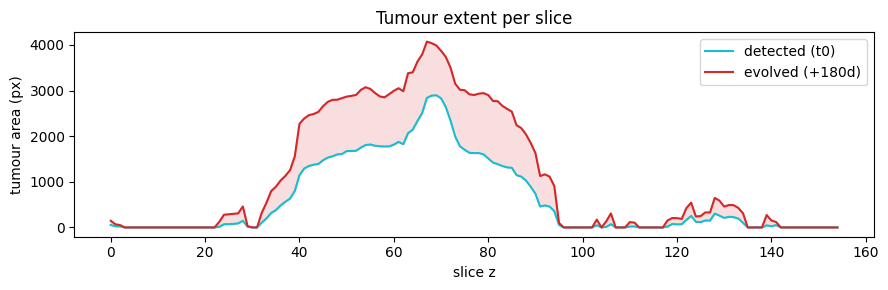

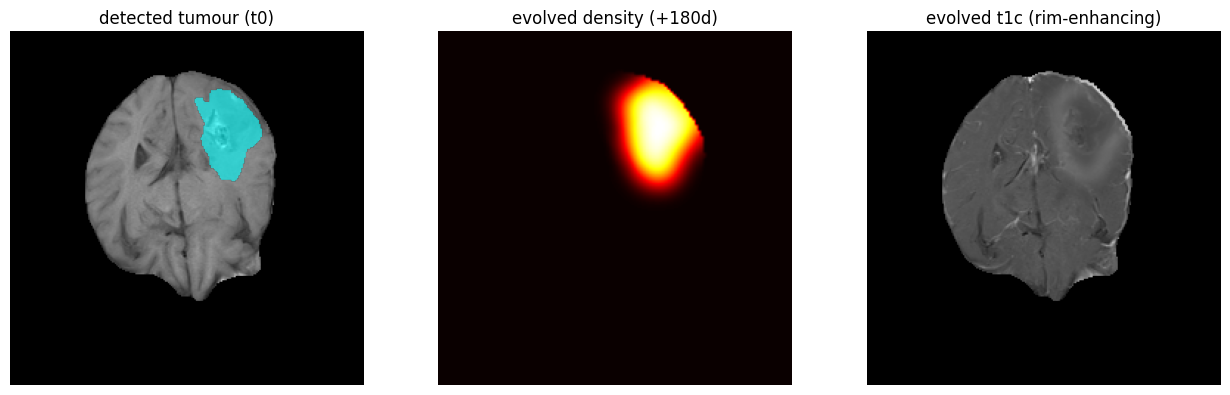

In [20]:
# Steps 2-3 — anatomy-aware FK evolution per slice, then realistic compositing
g = GROWTH_CFG['grid']
u_evolved_native = np.zeros((H, W, Z), dtype=np.float32)
centroid_snaps = None     # time-lapse snapshots at the tumour-centroid slice
n_evolved = 0
for z in range(Z):
    m = pred_mask_vol[:, :, z]
    if m.sum() == 0:
        continue
    seed = cv2.resize(m, (g, g), interpolation=cv2.INTER_NEAREST)
    seed = gaussian_filter(seed.astype(np.float32), GROWTH_CFG['seed_smooth_sigma'])
    seed = np.clip(seed / max(seed.max(), 1e-8), 0, 1)
    t1n_g = cv2.resize(minmax_norm_2d(patient['t1n'][:, :, z]), (g, g), interpolation=cv2.INTER_LINEAR)
    Dfield = build_D_field(t1n_g, seed)
    if z == z_tumor:
        centroid_snaps = fk_evolve_2d(seed, Dfield, rho_eff, GROWTH_CFG['horizon_days'],
                                      snapshots=GROWTH_CFG['snapshots'])
        u_T = centroid_snaps[GROWTH_CFG['horizon_days']]
    else:
        u_T = fk_evolve_2d(seed, Dfield, rho_eff, GROWTH_CFG['horizon_days'])
    u_evolved_native[:, :, z] = cv2.resize(u_T, (W, H), interpolation=cv2.INTER_LINEAR)
    n_evolved += 1

# Composite heterogeneous tumour appearance into all 4 modalities
alpha = GROWTH_CFG['blend_alpha']
vols_evolved = {}
for mod in ('t1n', 't1c', 't2w', 't2f'):
    out = np.zeros((H, W, Z), dtype=np.float32)
    for z in range(Z):
        base = minmax_norm_2d(patient[mod][:, :, z])
        u = np.clip(u_evolved_native[:, :, z], 0, 1) ** GROWTH_CFG['render_ease']
        out[:, :, z] = composite_tumor(u, base, mod, alpha) if u.max() > 1e-3 else base
    vols_evolved[mod] = out

# Quantitative growth (uses voxel volume)
det_vox = int((pred_mask_vol > 0.5).sum())
evo_vox = int((u_evolved_native > GROWTH_CFG['evo_thr']).sum())
det_mm3, evo_mm3 = det_vox * VOXEL_MM3, evo_vox * VOXEL_MM3
growth_x = evo_vox / max(det_vox, 1)
# equivalent spherical diameter (mm) from volume
sph_d = lambda v: 2.0 * (3.0 * v / (4.0 * np.pi)) ** (1 / 3) if v > 0 else 0.0
print(f'Evolved {n_evolved} tumour-bearing slice(s).')
print(f'Tumour volume  t0: {det_mm3/1000:.2f} mL ({det_vox:,} vox)  ->  '
      f'+{GROWTH_CFG["horizon_days"]:.0f}d: {evo_mm3/1000:.2f} mL ({evo_vox:,} vox)  = {growth_x:.2f}x')
print(f'Equivalent diameter: {sph_d(det_mm3):.1f} mm  ->  {sph_d(evo_mm3):.1f} mm')

# Per-slice tumour area curve
det_area = (pred_mask_vol > 0.5).sum(axis=(0, 1))
evo_area = (u_evolved_native > GROWTH_CFG['evo_thr']).sum(axis=(0, 1))
zz = np.arange(Z)
plt.figure(figsize=(9, 3))
plt.plot(zz, det_area, label='detected (t0)', color='tab:cyan')
plt.plot(zz, evo_area, label=f'evolved (+{GROWTH_CFG["horizon_days"]:.0f}d)', color='tab:red')
plt.fill_between(zz, det_area, evo_area, where=evo_area >= det_area, color='tab:red', alpha=0.15)
plt.xlabel('slice z'); plt.ylabel('tumour area (px)'); plt.legend()
plt.title('Tumour extent per slice'); plt.tight_layout(); plt.show()

# Quick look at the tumour-centroid slice
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
base0 = np.rot90(minmax_norm_2d(patient['t1n'][:, :, z_tumor]))
det0 = np.rot90((pred_mask_vol[:, :, z_tumor] > 0.5).astype(float))
ax[0].imshow(base0, cmap='gray')
ax[0].imshow(np.ma.masked_where(det0 < 0.5, det0), cmap='cool', alpha=0.6)
ax[0].set_title('detected tumour (t0)')
ax[1].imshow(np.rot90(u_evolved_native[:, :, z_tumor]), cmap='hot')
ax[1].set_title(f'evolved density (+{GROWTH_CFG["horizon_days"]:.0f}d)')
ax[2].imshow(np.rot90(vols_evolved['t1c'][:, :, z_tumor]), cmap='gray')
ax[2].set_title('evolved t1c (rim-enhancing)')
for a in ax:
    a.axis('off')
plt.tight_layout(); plt.show()


In [21]:
# Step 4 — nnU-Net RE-SEGMENTS the evolved slices (this mask conditions the GAN)
evolved_mask_vol = np.zeros((H, W, Z), dtype=np.float32)
for z in range(Z):
    img = np.stack([vols_evolved[m][:, :, z] for m in ('t1n', 't1c', 't2w', 't2f')], axis=-1)
    if float(np.abs(img).sum()) < 1.0:
        continue
    img_rs = cv2.resize(img, (sz, sz), interpolation=cv2.INTER_LINEAR)
    x = torch.from_numpy(np.transpose(img_rs, (2, 0, 1))).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(seg_tta(x)).squeeze().cpu().numpy().astype(np.float32)
    clean = post_process(prob, CFG['mask_threshold'])
    pred_native = cv2.resize(clean.astype(np.float32), (W, H), interpolation=cv2.INTER_NEAREST)
    evolved_mask_vol[:, :, z] = (pred_native > 0.5).astype(np.float32)

vols_evolved['mask'] = evolved_mask_vol     # <-- conditions Stage-5 GAN reconstruction
print(f'Re-segmented evolved volume: {int(evolved_mask_vol.sum()):,} tumor voxels '
      f'(t0 detected: {int(pred_mask_vol.sum()):,})')


Re-segmented evolved volume: 169,660 tumor voxels (t0 detected: 96,939)


In [22]:
# Step 5 — GAN reconstructs the EVOLVED volume (same sparse anchors + evolved mask)
print('Reconstructing the evolved volume with the GAN (full-quality path, second pass)...')
print('(this repeats the slow Stage-2 inference on the evolved slices)\n')
evolved_recon = reconstruct_full_volume_quality(G, vols_evolved, known_mask, input_mode='all5')
evolved_metrics = recon_metrics(vols_evolved, evolved_recon['post'], known_mask)
print('Evolved reconstruction done. (self-consistency PSNR/SSIM vs evolved anchors: '
      f"{evolved_metrics['psnr_unknown']:.2f} dB / {evolved_metrics['ssim_unknown']:.3f})")


Reconstructing the evolved volume with the GAN (full-quality path, second pass)...
(this repeats the slow Stage-2 inference on the evolved slices)

Evolved reconstruction done. (self-consistency PSNR/SSIM vs evolved anchors: 26.76 dB / 0.907)


Saved smoothed 3-panel GIF: /kaggle/working/full_pipeline/PatientID_0003_Timepoint_1_initial_vs_evolved.gif  (145 slices z=0..144, z_smooth_sigma=1.0)


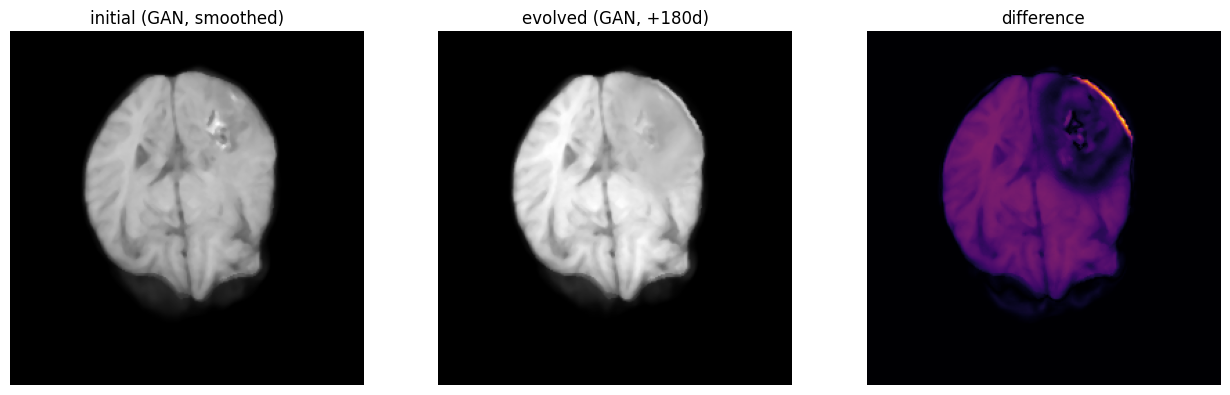

In [23]:
# 3-panel animation: initial | evolved | growth overlay — GAN panels SMOOTHED (de-flickered),
# overlay built on the RECONSTRUCTED slice (no ground truth used).
from scipy.ndimage import gaussian_filter1d
def to_u8(img):
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)

DISP = {
    'z_smooth_sigma': 1.0,            # Gaussian along z -> removes anchor/predicted flicker
    'clip_pct':       (1.0, 99.0),    # global contrast window -> removes brightness jitter
    'fill_alpha':     0.32,
    't0_color':       (0, 255, 255),  # current tumour      -> cyan
    'grow_color':     (255, 70, 70),  # predicted NEW growth -> red
}

def smooth_for_display(vol, z_sigma, clip):
    """De-flicker a sparse-reconstructed volume: one global contrast window (kills per-slice
       brightness jitter) + gentle z-smoothing (evens anchor vs predicted sharpness)."""
    v = vol.astype(np.float32)
    lo, hi = np.percentile(v, clip[0]), np.percentile(v, clip[1])
    v = np.clip((v - lo) / (hi - lo + 1e-8), 0, 1)
    return gaussian_filter1d(v, sigma=z_sigma, axis=2, mode='nearest')

init_disp = smooth_for_display(recon['post'], DISP['z_smooth_sigma'], DISP['clip_pct'])
evo_disp = smooth_for_display(evolved_recon['post'], DISP['z_smooth_sigma'], DISP['clip_pct'])

# tumour slice range (with margin)
tz = np.where(((pred_mask_vol > 0.5) | (u_evolved_native > GROWTH_CFG['evo_thr'])).sum(axis=(0, 1)) > 0)[0]
z0, z1 = (max(0, tz[0] - 3), min(Z - 1, tz[-1] + 3)) if len(tz) else (0, Z - 1)
IMG_ = init_disp.shape[0]
_rn = lambda a: cv2.resize(a.astype(np.float32), (IMG_, IMG_), interpolation=cv2.INTER_NEAREST)

def _contours(mask2d):
    cnts, _ = cv2.findContours(mask2d.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return cnts

frames = []
for z in range(z0, z1 + 1):
    lr = cv2.cvtColor(to_u8(np.rot90(init_disp[:, :, z])), cv2.COLOR_GRAY2RGB)
    rr = cv2.cvtColor(to_u8(np.rot90(evo_disp[:, :, z])), cv2.COLOR_GRAY2RGB)
    # overlay base = the RECONSTRUCTED initial slice (smoothed), not GT
    ov = cv2.cvtColor(to_u8(np.rot90(init_disp[:, :, z])), cv2.COLOR_GRAY2RGB)
    det = np.rot90(_rn(pred_mask_vol[:, :, z])) > 0.5
    evo = np.rot90(_rn((u_evolved_native[:, :, z] > GROWTH_CFG['evo_thr']).astype(np.float32))) > 0.5
    grow = evo & (~det)
    blend = ov.copy(); blend[det] = DISP['t0_color']; blend[grow] = DISP['grow_color']
    ov = cv2.addWeighted(blend, DISP['fill_alpha'], ov, 1 - DISP['fill_alpha'], 0)
    cv2.drawContours(ov, _contours(det), -1, DISP['t0_color'], 1)
    cv2.drawContours(ov, _contours(evo), -1, DISP['grow_color'], 1)
    sep = np.full((lr.shape[0], 3, 3), 255, np.uint8)
    row = np.ascontiguousarray(np.concatenate([lr, sep, rr, sep, ov], axis=1), np.uint8)
    w1 = lr.shape[1]
    cv2.putText(row, 'initial (recon)', (6, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(row, f'evolved +{GROWTH_CFG["horizon_days"]:.0f}d', (w1 + 9, 16),
                cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(row, 'growth: cyan=now red=new', (2 * w1 + 12, 16),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36, (255, 255, 255), 1, cv2.LINE_AA)
    cv2.putText(row, f'z={z}  {det_mm3/1000:.1f}->{evo_mm3/1000:.1f} mL (x{growth_x:.1f})',
                (6, row.shape[0] - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1, cv2.LINE_AA)
    row = cv2.resize(row, (row.shape[1] * 2, row.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
    frames.append(row)

evo_gif = CFG['out_dir'] / f"{CFG['patient']}_{CFG['timepoint']}_initial_vs_evolved.gif"
imageio.mimsave(evo_gif, frames, fps=CFG['gif_fps'], loop=0)
print(f'Saved smoothed 3-panel GIF: {evo_gif}  '
      f'({len(frames)} slices z={z0}..{z1}, z_smooth_sigma={DISP["z_smooth_sigma"]})')

# Static reference at the tumour-centroid slice (single frame -> no flicker)
zc = z_tumor
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(np.rot90(init_disp[:, :, zc]), cmap='gray'); ax[0].set_title('initial (GAN, smoothed)')
ax[1].imshow(np.rot90(evo_disp[:, :, zc]), cmap='gray')
ax[1].set_title(f'evolved (GAN, +{GROWTH_CFG["horizon_days"]:.0f}d)')
ax[2].imshow(np.rot90(np.abs(evo_disp[:, :, zc] - init_disp[:, :, zc])), cmap='inferno')
ax[2].set_title('difference')
for a in ax:
    a.axis('off')
plt.tight_layout(); plt.show()


Saved growth time-lapse GIF: /kaggle/working/full_pipeline/PatientID_0003_Timepoint_1_growth_timelapse.gif


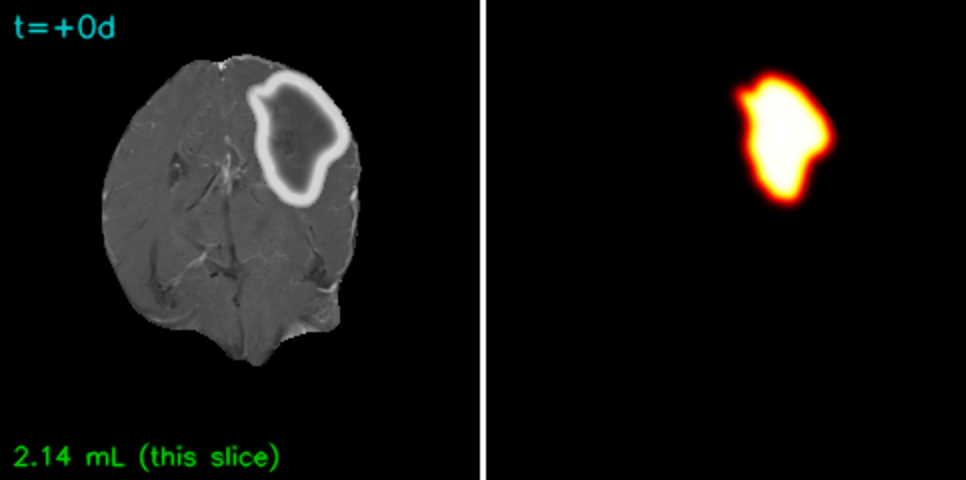

In [24]:
# Growth time-lapse at the tumour-centroid slice: evolved t1c (left) + density heatmap (right)
if centroid_snaps is not None and len(centroid_snaps):
    base = minmax_norm_2d(patient['t1c'][:, :, z_tumor])
    tl = []
    for t in sorted(centroid_snaps.keys()):
        u = np.clip(cv2.resize(centroid_snaps[t], (W, H), interpolation=cv2.INTER_LINEAR), 0, 1)
        ue = u ** GROWTH_CFG['render_ease']
        comp = composite_tumor(ue, base, 't1c', GROWTH_CFG['blend_alpha'])
        left = cv2.cvtColor(to_u8(np.rot90(comp)), cv2.COLOR_GRAY2RGB)
        heat = cv2.cvtColor(cv2.applyColorMap(to_u8(np.rot90(u)), cv2.COLORMAP_HOT), cv2.COLOR_BGR2RGB)
        sep = np.full((left.shape[0], 3, 3), 255, np.uint8)
        fr = np.ascontiguousarray(np.concatenate([left, sep, heat], axis=1), np.uint8)
        area_ml = int((u > GROWTH_CFG['evo_thr']).sum()) * VOXEL_MM3 / 1000.0
        cv2.putText(fr, f't=+{t:.0f}d', (6, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)
        cv2.putText(fr, f'{area_ml:.2f} mL (this slice)', (6, fr.shape[0] - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 0), 1, cv2.LINE_AA)
        fr = cv2.resize(fr, (fr.shape[1] * 2, fr.shape[0] * 2), interpolation=cv2.INTER_LINEAR)
        tl.append(fr)
    tl += [tl[-1]] * 3   # hold the final frame
    tlapse_gif = CFG['out_dir'] / f"{CFG['patient']}_{CFG['timepoint']}_growth_timelapse.gif"
    imageio.mimsave(tlapse_gif, tl, fps=2, loop=0)
    print('Saved growth time-lapse GIF:', tlapse_gif)

    from IPython.display import Image, display
    try:
        display(Image(filename=str(tlapse_gif)))
    except Exception as ex:
        print('(inline display skipped:', ex, ')')
else:
    print('No tumour-centroid snapshots (no tumour detected at z_tumor).')


In [25]:
# Export the initial + evolved volumes as grayscale slice stacks for the 3D viewer
# (brain-gan-viewer). Two stacks -> two GLB variants -> 'Volume' toggle in the viewer.
from PIL import Image

viewer_root = CFG['out_dir'] / 'viewer_slices'

def export_stack(vol, sub):
    d = viewer_root / sub
    d.mkdir(parents=True, exist_ok=True)
    for z in range(vol.shape[2]):
        sl = (np.clip(np.rot90(vol[:, :, z]), 0, 1) * 255).astype(np.uint8)
        Image.fromarray(sl, mode='L').save(d / f'slice_{z:03d}.png')
    return d, vol.shape[2]

# Use the de-flickered display volumes so the 3D mesh matches the GIF panels
init_vol = init_disp if 'init_disp' in globals() else recon['post']
evo_vol = evo_disp if 'evo_disp' in globals() else evolved_recon['post']
di, ni = export_stack(init_vol, 'initial')
de, ne = export_stack(evo_vol, 'evolved')
print(f'Exported {ni} initial slices -> {di}')
print(f'Exported {ne} evolved slices -> {de}')

hz = f"{GROWTH_CFG['horizon_days']:.0f}"
# ── Tumour mask stacks for the viewer's 3D tumour mesh ───────────────────────
# The masks live on the NATIVE grid (e.g. 240x240); the exported slices live on
# the DISPLAY grid (init_vol.shape[:2], e.g. 256x256). Resample with the same
# INTER_NEAREST -> rot90 -> threshold idiom the growth animation above uses, or
# the mesh lands squeezed into a corner of the brain it is meant to sit inside.
assert pred_mask_vol.shape == u_evolved_native.shape, (
    f'mask shape mismatch: pred={pred_mask_vol.shape} evo={u_evolved_native.shape}')
assert pred_mask_vol.shape[2] == init_vol.shape[2], (
    f'slice-count mismatch: masks {pred_mask_vol.shape[2]} vs volume {init_vol.shape[2]}')

_DH, _DW = init_vol.shape[:2]        # display grid the viewer's slice PNGs live on
_to_disp = lambda a: cv2.resize(a.astype(np.float32), (_DW, _DH),
                                interpolation=cv2.INTER_NEAREST)

def export_mask_stack(mask_bool, sub):
    d = viewer_root / sub
    d.mkdir(parents=True, exist_ok=True)
    n = 0
    for z in range(mask_bool.shape[2]):
        sl = np.rot90(_to_disp(mask_bool[:, :, z])) > 0.5
        n += int(sl.sum())
        Image.fromarray((sl.astype(np.uint8) * 255), mode='L').save(d / f'slice_{z:03d}.png')
    return d, n

# Thresholds match what metrics.json reports:
#   initial -> nnU-Net mask at 0.5      (metrics tumor.source nnunet_tta_postproc)
#   evolved -> FK density at evo_thr    (metrics tumor.source fisher_kpp_density)
_m_init = pred_mask_vol > 0.5
_m_evo = u_evolved_native > GROWTH_CFG['evo_thr']
_m_grow = _m_evo & ~_m_init          # new tissue only — rendered red in the viewer

dm_init, _n_init = export_mask_stack(_m_init, 'initial_mask')
dm_evo, _n_evo = export_mask_stack(_m_evo, 'evolved_mask')
dm_grow, _n_grow = export_mask_stack(_m_grow, 'growth_mask')

_area = (_DH * _DW) / (pred_mask_vol.shape[0] * pred_mask_vol.shape[1])
print(f'\nMask stacks -> {viewer_root}')
print(f'  grid: native {pred_mask_vol.shape[:2]} -> display {(_DH, _DW)}  '
      f'(in-plane area x{_area:.3f})')
print(f'  {"stack":14s}{"native vox":>13s}{"display vox":>13s}')
for _nm, _m, _nd in (('initial_mask', _m_init, _n_init),
                     ('evolved_mask', _m_evo, _n_evo),
                     ('growth_mask', _m_grow, _n_grow)):
    print(f'  {_nm:14s}{int(_m.sum()):>13,}{_nd:>13,}')
print('  native counts are what metrics.json reports (physical mL);')
print('  display counts are what the mesh is built from (viewer geometry).')
_sum, _evo = int(_m_init.sum()) + int(_m_grow.sum()), int(_m_evo.sum())
print(f'  containment: initial + growth = {_sum:,} vs evolved {_evo:,}  -> initial '
      f'{"IS" if _sum == _evo else "IS NOT"} a subset of evolved')

print('\nBuild the 3D viewer with BOTH volumes (run inside brain-gan-viewer/):')
print(f'  python generate_brain.py --input_dir "{di}" --variant initial --variant_label "Initial"')
print(f'  python generate_brain.py --input_dir "{de}" --variant evolved --variant_label "Evolved +{hz}d"')
print('  python prepare_github_pages.py --viewer_src viewer --deploy_dst docs/brain-viewer')
print('\n(The next cell writes metrics.json and re-prints these commands with --metrics_json.)')
print('Then open the viewer — the \'Volume\' toggle switches Initial <-> Evolved.')


/tmp/ipykernel_22/2938914524.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(sl, mode='L').save(d / f'slice_{z:03d}.png')


Exported 155 initial slices -> /kaggle/working/full_pipeline/viewer_slices/initial
Exported 155 evolved slices -> /kaggle/working/full_pipeline/viewer_slices/evolved


/tmp/ipykernel_22/2938914524.py:45: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((sl.astype(np.uint8) * 255), mode='L').save(d / f'slice_{z:03d}.png')



Mask stacks -> /kaggle/working/full_pipeline/viewer_slices
  grid: native (240, 240) -> display (256, 256)  (in-plane area x1.138)
  stack            native vox  display vox
  initial_mask         96,939      110,227
  evolved_mask        170,555      193,530
  growth_mask          73,674       83,375
  native counts are what metrics.json reports (physical mL);
  display counts are what the mesh is built from (viewer geometry).
  containment: initial + growth = 170,613 vs evolved 170,555  -> initial IS NOT a subset of evolved

Build the 3D viewer with BOTH volumes (run inside brain-gan-viewer/):
  python generate_brain.py --input_dir "/kaggle/working/full_pipeline/viewer_slices/initial" --variant initial --variant_label "Initial"
  python generate_brain.py --input_dir "/kaggle/working/full_pipeline/viewer_slices/evolved" --variant evolved --variant_label "Evolved +180d"
  python prepare_github_pages.py --viewer_src viewer --deploy_dst docs/brain-viewer

(The next cell writes metrics.j

In [26]:
# Export metrics.json for the 3D viewer's quantitative panel (schema oracle.metrics/1).
# One file per variant; the viewer treats a missing/invalid file as "hide the panel".
import json as _json, datetime as _dt, math as _math

def _finite(o, path='root'):
    """JSON has no NaN/Infinity — json.dumps emits them anyway and JSON.parse
    would then throw in the browser. Fail here instead."""
    if isinstance(o, dict):
        for k, v in o.items():
            _finite(v, f'{path}.{k}')
    elif isinstance(o, list):
        for i, v in enumerate(o):
            _finite(v, f'{path}[{i}]')
    elif isinstance(o, float):
        assert _math.isfinite(o), f'non-finite value at {path}: {o}'
    return o


def _shared_block():
    return {
        'schema': 'oracle.metrics/1',
        'generated_at': _dt.datetime.now(_dt.timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ'),
        'case': {'patient': CFG['patient'], 'timepoint': CFG['timepoint'],
                 'dataset': 'MU-Glioma-Post'},
        'voxel': {'spacing_mm': [float(v) for v in VOX], 'volume_mm3': float(VOXEL_MM3)},
        'horizon_days': float(GROWTH_CFG['horizon_days']),
        'classification': (None if not CLS_AVAILABLE or cls_result is None else {
            'label': cls_result['label'],
            'confidence': float(cls_result['confidence']),
            'probabilities': {k: float(v) for k, v in cls_result['probabilities'].items()},
            'model': 'EfficientNet-B3',
            'trained_on': 'brain-tumor-mri-dataset (4-class, pre-operative)',
            'out_of_distribution': True,
            'ood_note': ('Trained on pre-operative 4-class JPEGs; applied to post-operative '
                         'MU-Glioma-Post slices. Demonstration only — no diagnostic weight.'),
            'aggregation': f"top{cls_result['topk']}_tumor_evidence_mean_softmax",
            'n_slices': int(cls_result['n_slices']),
            'computed_on': 'initial',
        }),
        'provenance': {'notebook': 'full_pipeline_testing.ipynb',
                       'seg_ckpt': CFG['seg_ckpt'].name, 'gan_ckpt': CFG['gan_ckpt'].name,
                       'pinn_ckpt': CFG['pinn_ckpt'].name,
                       'cls_ckpt': (Path(CFG['cls_ckpt']).name if CLS_AVAILABLE else None)},
    }


def _tumor(vox, mm3, thr, source):
    return {'voxels': int(vox), 'volume_mm3': float(mm3), 'volume_ml': float(mm3) / 1000.0,
            'equivalent_diameter_mm': float(sph_d(mm3)), 'threshold': float(thr),
            'source': source}


m_init = dict(_shared_block(), variant='initial', label='Initial',
              tumor=_tumor(det_vox, det_mm3, CFG['mask_threshold'], 'nnunet_tta_postproc'),
              tumor_resegmented=None, growth=None)

_reseg_vox = int((evolved_mask_vol > 0.5).sum())
m_evo = dict(_shared_block(), variant='evolved',
             label=f"Evolved +{GROWTH_CFG['horizon_days']:.0f}d",
             tumor=_tumor(evo_vox, evo_mm3, GROWTH_CFG['evo_thr'], 'fisher_kpp_density'),
             tumor_resegmented=_tumor(_reseg_vox, _reseg_vox * VOXEL_MM3,
                                      CFG['mask_threshold'], 'nnunet_tta_postproc'),
             growth={'ratio': float(growth_x),
                     'delta_volume_ml': float(evo_mm3 - det_mm3) / 1000.0,
                     'delta_diameter_mm': float(sph_d(evo_mm3) - sph_d(det_mm3)),
                     'reference_variant': 'initial'})

mi = viewer_root / 'metrics_initial.json'
me = viewer_root / 'metrics_evolved.json'
mi.write_text(_json.dumps(_finite(m_init), indent=2))
me.write_text(_json.dumps(_finite(m_evo), indent=2))
print(f'Wrote {mi}\nWrote {me}')

hz = f"{GROWTH_CFG['horizon_days']:.0f}"
print('\nBuild the viewer WITH the metrics panel (run inside brain-gan-viewer/):')
print(f'  python generate_brain.py --input_dir "{di}" --variant initial '
      f'--variant_label "Initial" --metrics_json "{mi}" --tumor_dir "{dm_init}"')
print(f'  python generate_brain.py --input_dir "{de}" --variant evolved '
      f'--variant_label "Evolved +{hz}d" --metrics_json "{me}" '
      f'--tumor_dir "{dm_init}" --growth_dir "{dm_grow}"')
print('\n(Adding the tumour mesh to an EXISTING build, without rewriting 54 MB of')
print(' brain mesh and slice PNGs, is the --tumor_only path:)')
print(f'  python generate_brain.py --tumor_only --variant initial --tumor_dir "{dm_init}"')
print(f'  python generate_brain.py --tumor_only --variant evolved '
      f'--tumor_dir "{dm_init}" --growth_dir "{dm_grow}"')
print('  # then copy viewer/assets/* into ../docs/brain-viewer/assets/ and commit')

Wrote /kaggle/working/full_pipeline/viewer_slices/metrics_initial.json
Wrote /kaggle/working/full_pipeline/viewer_slices/metrics_evolved.json

Build the viewer WITH the metrics panel (run inside brain-gan-viewer/):
  python generate_brain.py --input_dir "/kaggle/working/full_pipeline/viewer_slices/initial" --variant initial --variant_label "Initial" --metrics_json "/kaggle/working/full_pipeline/viewer_slices/metrics_initial.json" --tumor_dir "/kaggle/working/full_pipeline/viewer_slices/initial_mask"
  python generate_brain.py --input_dir "/kaggle/working/full_pipeline/viewer_slices/evolved" --variant evolved --variant_label "Evolved +180d" --metrics_json "/kaggle/working/full_pipeline/viewer_slices/metrics_evolved.json" --tumor_dir "/kaggle/working/full_pipeline/viewer_slices/initial_mask" --growth_dir "/kaggle/working/full_pipeline/viewer_slices/growth_mask"

(Adding the tumour mesh to an EXISTING build, without rewriting 54 MB of
 brain mesh and slice PNGs, is the --tumor_only path:)

## Pipeline Summary

All three trained ORACLE models ran end-to-end on `PatientID_0003/Timepoint_1`,
cascaded segmentation → reconstruction → growth.

In [27]:
summary = pd.DataFrame([
    {'stage': '0b · Classification', 'model': 'EfficientNet-B3 (+ Grad-CAM)',
     'checkpoint': (Path(CFG['cls_ckpt']).name if CLS_AVAILABLE else '—'),
     'key_result': (f"{cls_result['label']} ({cls_result['confidence']*100:.1f}%) "
                    f"[out-of-distribution demo]" if cls_result else 'skipped (no checkpoint)')},
    {'stage': '1 · Segmentation', 'model': 'nnU-Net 2D (EMA + 16-aug TTA)',
     'checkpoint': CFG['seg_ckpt'].name,
     'key_result': f"mean per-slice Dice = {np.mean(seg_dices):.3f}"},
    {'stage': '2 · Reconstruction', 'model': 'Fast2p5D GAN (multi-scale + TTA)',
     'checkpoint': CFG['gan_ckpt'].name,
     'key_result': (f"unknown-slice PSNR = {metrics['psnr_unknown']:.2f} dB, "
                    f"SSIM = {metrics['ssim_unknown']:.3f}")},
    {'stage': '3 · Growth (PINN)', 'model': 'Inverse Fisher–KPP PINN',
     'checkpoint': CFG['pinn_ckpt'].name,
     'key_result': f"D_wm={D_wm:.2e}, D_gm={D_gm:.2e}, rho={rho:.2e}"},
    {'stage': '4 · Evolution', 'model': 'anatomy-aware FK -> nnU-Net -> GAN',
     'checkpoint': '—',
     'key_result': (f"{det_mm3/1000:.1f}->{evo_mm3/1000:.1f} mL (x{growth_x:.1f}) "
                    f"over {GROWTH_CFG['horizon_days']:.0f} d")},
])
print(summary.to_string(index=False))
print('\nArtifacts written to:', CFG['out_dir'])
for p in sorted(CFG['out_dir'].glob('*.gif')):
    print('  -', p.name)


              stage                              model            checkpoint                                  key_result
0b · Classification       EfficientNet-B3 (+ Grad-CAM) best_effnetb3_cls.pth   glioma (74.7%) [out-of-distribution demo]
   1 · Segmentation      nnU-Net 2D (EMA + 16-aug TTA)     best_nnunet2d.pth                 mean per-slice Dice = 0.802
 2 · Reconstruction   Fast2p5D GAN (multi-scale + TTA) G_joint_epoch_022.pth unknown-slice PSNR = 27.57 dB, SSIM = 0.906
  3 · Growth (PINN)            Inverse Fisher–KPP PINN  pinn_tumor_growth.pt  D_wm=2.67e-06, D_gm=3.46e-04, rho=1.24e-04
      4 · Evolution anatomy-aware FK -> nnU-Net -> GAN                     —            96.9->170.6 mL (x1.8) over 180 d

Artifacts written to: /kaggle/working/full_pipeline
  - PatientID_0003_Timepoint_1_growth_timelapse.gif
  - PatientID_0003_Timepoint_1_initial_vs_evolved.gif
  - PatientID_0003_Timepoint_1_recon.gif
  - pinn_growth.gif
